In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import xeofs as xe
from pygments.modeline import modeline_re

from geometry_izzyv1 import grad_sphere
from regression_izzyv1 import linregress_3D
import cartopy.crs as ccrs
crs = ccrs.PlateCarree()
import warnings
import os
from pyproj import Proj, Transformer
import requests
from bs4 import BeautifulSoup
#import copernicusmarine as cm
warnings.filterwarnings('ignore')

In [3]:
# dot dataset
gridtype = 'remapcon'
path = '/Users/iw2g24/PycharmProjects/SSH_project/'
print(path)
fig_path = '/Users/iw2g24/PycharmProjects/SSH_project/results/NPP_mca/'
ds = xr.open_dataset(path + 'Data/dot_all_30bmedian_goco05c_sig3_1.nc')
print(ds)
# ERA5 remap dataset
ds_era5 = xr.open_dataset(path + 'Data/ERA5_u10v10_Antartica_2000-2023_' + gridtype + '.nc')

/Users/iw2g24/PycharmProjects/SSH_project/
<xarray.Dataset> Size: 109MB
Dimensions:          (longitude: 360, latitude: 64, time: 196, edge_lat: 65,
                      edge_lon: 361)
Coordinates:
  * longitude        (longitude) float64 3kB -179.5 -178.5 ... 178.5 179.5
  * latitude         (latitude) float64 512B -81.75 -81.25 ... -50.75 -50.25
  * time             (time) datetime64[ns] 2kB 2002-07-01 ... 2018-10-01
  * edge_lat         (edge_lat) float64 520B -82.0 -81.5 -81.0 ... -50.5 -50.0
  * edge_lon         (edge_lon) float64 3kB -180.0 -179.0 -178.0 ... 179.0 180.0
Data variables:
    dot              (longitude, latitude, time) float64 36MB ...
    ug               (longitude, latitude, time) float64 36MB ...
    vg               (longitude, latitude, time) float64 36MB ...
    land_mask        (longitude, latitude) float64 184kB ...
    intersat_offset  float64 8B ...
Attributes:
    history:      Created 08/01/2022, 00:5223
    description:  ENVISAT + CryoSat2 altimetry 

In [4]:
path_ds = '/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/'
print(path_ds)
WSC_eumetsat_ds = xr.open_dataset(path_ds + 'WSC_eumetsat_masked_v2.nc')
WSC_nsidc_ds = xr.open_dataset(path_ds + 'WSC_nsidc_masked_v2.nc')
sidc_eumetsat_ds = xr.open_dataset(path_ds + 'sidc_eumetsat_masked_v2.nc')
sidc_eumetsat_ds = sidc_eumetsat_ds.rename({'__xarray_dataarray_variable__': 'sidc'})
sidc_nsidc_ds = xr.open_dataset(path_ds + 'sidc_nsidc_masked_v2.nc')
sidc_nsidc_ds = sidc_nsidc_ds.rename({'__xarray_dataarray_variable__': 'sidc'})
tau_nsidc_ds = xr.open_dataset(path_ds + 'tau_nsidc_ds_v4.nc')
tau_eumetsat_ds = xr.open_dataset(path_ds + 'tau_eumetsat_ds_v4.nc')
# tau_nsidc_ds = xr.open_dataset(path + 'tau_nsidc_ds_v3.nc')
# tau_eumetsat_ds = xr.open_dataset(path + 'tau_eumetsat_ds_v3.nc')
dot_masked_ds = xr.open_dataset(path_ds + 'dot_masked.nc')
OSC_eumetsat_ds = xr.open_dataset(path_ds+'OSC_eumetsat_ds_v2.nc')
OSC_nsidc_ds = xr.open_dataset(path_ds+'OSC_nsidc_ds_v2.nc')

/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/


In [5]:
ds_NPP = xr.open_dataset(path + 'Data/NPP_anomalies' + '.nc')
print(ds_NPP)

ds_NPP_masked = xr.open_dataset(path + 'Data/NPP_anomalies_masked' + '.nc')
print(ds_NPP_masked)

ds_NPP = ds_NPP.transpose('year', 'lat', 'lon')  # shape becomes (22, 480, 4320)
ds_NPP = ds_NPP.sortby(['lat', 'lon'])


ds_NPP_masked = ds_NPP_masked.transpose('year', 'lat', 'lon')  # shape becomes (22, 480, 4320)
ds_NPP_masked = ds_NPP_masked.sortby(['lat', 'lon'])
print(ds_NPP_masked)
print(ds_NPP)




<xarray.Dataset> Size: 365MB
Dimensions:       (lat: 480, lon: 4320, year: 22)
Coordinates:
  * lat           (lat) float64 4kB -50.12 -50.21 -50.29 ... -89.96 -90.04
  * lon           (lon) float64 35kB -179.9 -179.8 -179.7 ... 179.9 180.0 180.0
  * year          (year) float64 176B 2.003e+03 2.004e+03 ... 2.024e+03
Data variables:
    OpenOceanNPP  (year, lon, lat) float64 365MB ...
<xarray.Dataset> Size: 730MB
Dimensions:                (lat: 480, lon: 4320, year: 22)
Coordinates:
  * lat                    (lat) float64 4kB -50.12 -50.21 ... -89.96 -90.04
  * lon                    (lon) float64 35kB -179.9 -179.8 ... 180.0 180.0
  * year                   (year) float64 176B 2.003e+03 2.004e+03 ... 2.024e+03
Data variables:
    OpenOceanNPP_masked    (year, lon, lat) float64 365MB ...
    ShelfRegionNPP_masked  (year, lon, lat) float64 365MB ...
<xarray.Dataset> Size: 730MB
Dimensions:                (lat: 480, lon: 4320, year: 22)
Coordinates:
  * lat                    (lat) flo

In [6]:
# time
time_era5 = ds_era5['time'].values
time_dot = ds['time'].values
time_NPP = ds_NPP['year'].values
time_tau = tau_nsidc_ds['time'].values
time_sidc_eumetsat = sidc_eumetsat_ds['time'].values

In [7]:
#create new NPP dates where they are monthly (not annual)
start_year = int(time_NPP[0]) -1
end_year = int(time_NPP[-1])
monthly_NPP_time = pd.date_range(start=f'{start_year}-07-01',end=f'{end_year}-06-30', freq='MS')
monthly_NPP_time = monthly_NPP_time.strftime('%Y-%m-%dT%H:%M:%S.%f000')
print(monthly_NPP_time)
print(time_NPP)

Index(['2002-07-01T00:00:00.000000000', '2002-08-01T00:00:00.000000000',
       '2002-09-01T00:00:00.000000000', '2002-10-01T00:00:00.000000000',
       '2002-11-01T00:00:00.000000000', '2002-12-01T00:00:00.000000000',
       '2003-01-01T00:00:00.000000000', '2003-02-01T00:00:00.000000000',
       '2003-03-01T00:00:00.000000000', '2003-04-01T00:00:00.000000000',
       ...
       '2023-09-01T00:00:00.000000000', '2023-10-01T00:00:00.000000000',
       '2023-11-01T00:00:00.000000000', '2023-12-01T00:00:00.000000000',
       '2024-01-01T00:00:00.000000000', '2024-02-01T00:00:00.000000000',
       '2024-03-01T00:00:00.000000000', '2024-04-01T00:00:00.000000000',
       '2024-05-01T00:00:00.000000000', '2024-06-01T00:00:00.000000000'],
      dtype='object', length=264)
[2003. 2004. 2005. 2006. 2007. 2008. 2009. 2010. 2011. 2012. 2013. 2014.
 2015. 2016. 2017. 2018. 2019. 2020. 2021. 2022. 2023. 2024.]


In [8]:
#print(time_era5)
print(time_dot[0],time_dot[-1])
print(time_era5[30],time_era5[225])
print(time_tau[0], time_tau[-1])
print(time_sidc_eumetsat[0], time_sidc_eumetsat[-1])
print(monthly_NPP_time[0],monthly_NPP_time[195])


2002-07-01T00:00:00.000000000 2018-10-01T00:00:00.000000000
2002-07-01T00:00:00.000000000 2018-10-01T00:00:00.000000000
2002-07-01T00:00:00.000000000 2018-10-01T00:00:00.000000000
2002-07-01T00:00:00.000000000 2018-10-01T00:00:00.000000000
2002-07-01T00:00:00.000000000 2018-10-01T00:00:00.000000000


In [9]:
tstart_dot = 0
tend_dot = -1
tstart_tau = 0
tend_tau = -1
tstart_era5_NPP = 30
tstart_era5 = 30
tend_era5 = 226 # +1 respect cell above
tstart_NPP = 0
tend_NPP = 196 #+1 wrt cell above

In [10]:
#create array with monthly average contribution to annual integrated (summed) NNP
ann_NPP = ds_NPP['OpenOceanNPP'].values
monthly_NPP = np.repeat(ann_NPP/12, repeats = 12, axis = 0)
monthly_NPP = np.roll(monthly_NPP, shift = -6, axis = 0)
print(len(ann_NPP), len(monthly_NPP))
# #select appropriate times - match to dot length/extent
# monthly_NPP = monthly_NPP[tstart_NPP:tend_NPP]
# print(len(monthly_NPP))

22 264


In [11]:
ann_NPP_ocean_masked = ds_NPP_masked['OpenOceanNPP_masked'].values
monthly_NPP_ocean_masked = np.repeat(ann_NPP_ocean_masked/12, repeats = 12, axis = 0)
monthly_NPP_ocean_masked = np.roll(monthly_NPP_ocean_masked, shift = -6, axis = 0)
print(len(ann_NPP_ocean_masked), len(monthly_NPP_ocean_masked))

22 264


In [12]:
ann_NPP_shelf_masked = ds_NPP_masked['ShelfRegionNPP_masked'].values
monthly_NPP_shelf_masked = np.repeat(ann_NPP_shelf_masked/12, repeats = 12, axis = 0)
monthly_NPP_shelf_masked = np.roll(monthly_NPP_shelf_masked, shift = -6, axis = 0)
print(len(ann_NPP_shelf_masked), len(monthly_NPP_shelf_masked))

22 264


In [13]:
print(monthly_NPP.shape)
print(monthly_NPP_time.shape)

(264, 480, 4320)
(264,)


In [14]:
#add monthly dates and NPP values to ds_NPP
lon_NPP = ds_NPP['lon'].values
lat_NPP = ds_NPP['lat'].values
ds_NPP['monthly_NPP']= (('monthly_NPP_time', 'lat_NPP', 'lon_NPP'), monthly_NPP)
ds_NPP = ds_NPP.assign_coords(monthly_NPP_time = ('monthly_NPP_time', monthly_NPP_time))
ds_NPP = ds_NPP.fillna(0)

print(ds_NPP)

<xarray.Dataset> Size: 5GB
Dimensions:           (year: 22, lat: 480, lon: 4320, monthly_NPP_time: 264,
                       lat_NPP: 480, lon_NPP: 4320)
Coordinates:
  * lat               (lat) float64 4kB -90.04 -89.96 -89.87 ... -50.21 -50.12
  * lon               (lon) float64 35kB -179.9 -179.8 -179.7 ... 180.0 180.0
  * year              (year) float64 176B 2.003e+03 2.004e+03 ... 2.024e+03
  * monthly_NPP_time  (monthly_NPP_time) object 2kB '2002-07-01T00:00:00.0000...
Dimensions without coordinates: lat_NPP, lon_NPP
Data variables:
    OpenOceanNPP      (year, lat, lon) float64 365MB 0.0 0.0 0.0 ... 15.99 0.0
    monthly_NPP       (monthly_NPP_time, lat_NPP, lon_NPP) float64 4GB 0.0 .....


In [15]:
ds_NPP_masked['monthly_NPP_ocean_masked']= (('monthly_NPP_time', 'lat_NPP', 'lon_NPP'), monthly_NPP_ocean_masked)
ds_NPP_masked['monthly_NPP_shelf_masked']= (('monthly_NPP_time', 'lat_NPP', 'lon_NPP'), monthly_NPP_shelf_masked)
ds_NPP_masked = ds_NPP_masked.assign_coords(monthly_NPP_time = ('monthly_NPP_time', monthly_NPP_time))
ds_NPP_masked = ds_NPP_masked.fillna(0)

In [16]:
# change coordinates from (lon,lat,time) to (time,lat,lon) as ERA5
lon = ds['longitude'].values; lat = ds['latitude'].values
dot_all = ds['dot'].values
dot = np.zeros((dot_all.shape[2], dot_all.shape[1], dot_all.shape[0]))
for t in range(0,dot_all.shape[2]):
    for i in range(0,dot_all.shape[1]):
        for j in range(0,dot_all.shape[0]):
            dot[t,i,j] = dot_all[j,i,t].copy()
seamask = dot[0].copy()/dot[0]
seamask[seamask == 0] = np.nan
del dot_all

months = time_dot.astype('datetime64[M]').astype(int) % 12 + 1

# linear regression in time on each grid point
n,slope,intercept,p_val,r_square,rmse = linregress_3D(dot)
# remove trend for dot
xt = np.zeros(dot.shape)
for t in range(0,dot.shape[0]):
    xt[t] = t
dot_detrended = dot - (slope*xt + intercept)

# find and remove seasonality from dot_detrended and ws_curl_detrended
dot_seas = np.zeros((12,dot.shape[1],dot.shape[2]));
for m in range(1,13):
    dot_seas[m-1] = np.nanmean(dot_detrended[np.where(months==m)], axis=0)


# remove seasonality
dot_final = np.zeros(dot_detrended.shape)
for i,m in enumerate(months):
    dot_final[i] = dot_detrended[i] - dot_seas[m-1]


In [17]:
from scipy.interpolate import griddata

#regrid SSH to match NPP
ssh_data = dot_final[tstart_dot::]
source_lat = ds['latitude'].values
source_lon = ds['longitude'].values

print(source_lat.shape)
print(source_lon.shape)

source_lon2d, source_lat2d = np.meshgrid(source_lon, source_lat)
source_points = np.column_stack((source_lat2d.ravel(), source_lon2d.ravel()))

target_lat = ds_NPP['lat'].values
target_lon = ds_NPP['lon'].values

print(target_lat.shape)
print(target_lon.shape)

target_lon2d, target_lat2d = np.meshgrid(target_lon, target_lat)
target_points = np.column_stack((target_lat2d.ravel(), target_lon2d.ravel()))

num_times = ssh_data.shape[0]
regridded_ssh = np.empty((num_times, len(target_lat), len(target_lon)))

# Loop over time
for t in range(num_times):
    print(f"Regridding time step {t + 1}/{num_times}...")

    # Flatten SSH data at time t and interpolate to target grid
    values = ssh_data[t].ravel()
    interpolated = griddata(source_points, values, target_points, method='linear')

    # Reshape the interpolated values back to the target grid

    regridded_ssh[t] = interpolated.reshape((len(target_lat), len(target_lon)))


(64,)
(360,)
(480,)
(4320,)
Regridding time step 1/196...
Regridding time step 2/196...
Regridding time step 3/196...
Regridding time step 4/196...
Regridding time step 5/196...
Regridding time step 6/196...
Regridding time step 7/196...
Regridding time step 8/196...
Regridding time step 9/196...
Regridding time step 10/196...
Regridding time step 11/196...
Regridding time step 12/196...
Regridding time step 13/196...
Regridding time step 14/196...
Regridding time step 15/196...
Regridding time step 16/196...
Regridding time step 17/196...
Regridding time step 18/196...
Regridding time step 19/196...
Regridding time step 20/196...
Regridding time step 21/196...
Regridding time step 22/196...
Regridding time step 23/196...
Regridding time step 24/196...
Regridding time step 25/196...
Regridding time step 26/196...
Regridding time step 27/196...
Regridding time step 28/196...
Regridding time step 29/196...
Regridding time step 30/196...
Regridding time step 31/196...
Regridding time step

In [18]:
from scipy.interpolate import griddata

#regrid SSH to match NPP
# wsc_data = ws_curl_final[6::]
wsc_data = WSC_nsidc_ds['WSC']
wsc_data = wsc_data.isel(time=slice(0, None))


source_lat = ds['latitude'].values
source_lon = ds['longitude'].values

print(source_lat.shape)
print(source_lon.shape)

source_lon2d, source_lat2d = np.meshgrid(source_lon, source_lat)
source_points = np.column_stack((source_lat2d.ravel(), source_lon2d.ravel()))

target_lat = ds_NPP['lat'].values
target_lon = ds_NPP['lon'].values

print(target_lat.shape)
print(target_lon.shape)

target_lon2d, target_lat2d = np.meshgrid(target_lon, target_lat)
target_points = np.column_stack((target_lat2d.ravel(), target_lon2d.ravel()))

num_times = wsc_data.shape[0]
regridded_wsc_nsidc = np.empty((num_times, len(target_lat), len(target_lon)))

# Loop over time
for t in range(num_times):
    print(f"Regridding time step {t + 1}/{num_times}...")

    # Flatten SSH data at time t and interpolate to target grid
    values = wsc_data[t].values.ravel()
    interpolated = griddata(source_points, values, target_points, method='linear')

    # Reshape the interpolated values back to the target grid

    regridded_wsc_nsidc[t] = interpolated.reshape((len(target_lat), len(target_lon)))


(64,)
(360,)
(480,)
(4320,)
Regridding time step 1/196...
Regridding time step 2/196...
Regridding time step 3/196...
Regridding time step 4/196...
Regridding time step 5/196...
Regridding time step 6/196...
Regridding time step 7/196...
Regridding time step 8/196...
Regridding time step 9/196...
Regridding time step 10/196...
Regridding time step 11/196...
Regridding time step 12/196...
Regridding time step 13/196...
Regridding time step 14/196...
Regridding time step 15/196...
Regridding time step 16/196...
Regridding time step 17/196...
Regridding time step 18/196...
Regridding time step 19/196...
Regridding time step 20/196...
Regridding time step 21/196...
Regridding time step 22/196...
Regridding time step 23/196...
Regridding time step 24/196...
Regridding time step 25/196...
Regridding time step 26/196...
Regridding time step 27/196...
Regridding time step 28/196...
Regridding time step 29/196...
Regridding time step 30/196...
Regridding time step 31/196...
Regridding time step

In [19]:
from scipy.interpolate import griddata

#regrid SSH to match NPP
# wsc_data = ws_curl_final[6::]
wsc_data = WSC_eumetsat_ds['WSC']
wsc_data = wsc_data.isel(time=slice(0, None))


source_lat = ds['latitude'].values
source_lon = ds['longitude'].values

print(source_lat.shape)
print(source_lon.shape)

source_lon2d, source_lat2d = np.meshgrid(source_lon, source_lat)
source_points = np.column_stack((source_lat2d.ravel(), source_lon2d.ravel()))

target_lat = ds_NPP['lat'].values
target_lon = ds_NPP['lon'].values

print(target_lat.shape)
print(target_lon.shape)

target_lon2d, target_lat2d = np.meshgrid(target_lon, target_lat)
target_points = np.column_stack((target_lat2d.ravel(), target_lon2d.ravel()))

num_times = wsc_data.shape[0]
regridded_wsc_eumetsat = np.empty((num_times, len(target_lat), len(target_lon)))

# Loop over time
for t in range(num_times):
    print(f"Regridding time step {t + 1}/{num_times}...")

    # Flatten SSH data at time t and interpolate to target grid
    values = wsc_data[t].values.ravel()
    interpolated = griddata(source_points, values, target_points, method='linear')

    # Reshape the interpolated values back to the target grid

    regridded_wsc_eumetsat[t] = interpolated.reshape((len(target_lat), len(target_lon)))


(64,)
(360,)
(480,)
(4320,)
Regridding time step 1/196...
Regridding time step 2/196...
Regridding time step 3/196...
Regridding time step 4/196...
Regridding time step 5/196...
Regridding time step 6/196...
Regridding time step 7/196...
Regridding time step 8/196...
Regridding time step 9/196...
Regridding time step 10/196...
Regridding time step 11/196...
Regridding time step 12/196...
Regridding time step 13/196...
Regridding time step 14/196...
Regridding time step 15/196...
Regridding time step 16/196...
Regridding time step 17/196...
Regridding time step 18/196...
Regridding time step 19/196...
Regridding time step 20/196...
Regridding time step 21/196...
Regridding time step 22/196...
Regridding time step 23/196...
Regridding time step 24/196...
Regridding time step 25/196...
Regridding time step 26/196...
Regridding time step 27/196...
Regridding time step 28/196...
Regridding time step 29/196...
Regridding time step 30/196...
Regridding time step 31/196...
Regridding time step

In [20]:
from scipy.interpolate import griddata

#regrid oss to match NPP
oss_data = tau_eumetsat_ds['ocean_surface_stress']
oss_data = oss_data.isel(time=slice(0, None))
source_lat = tau_eumetsat_ds['lat'].values
source_lon = tau_eumetsat_ds['lon'].values

print(source_lat.shape)
print(source_lon.shape)

source_lon2d, source_lat2d = np.meshgrid(source_lon, source_lat)
source_points = np.column_stack((source_lat2d.ravel(), source_lon2d.ravel()))

target_lat = ds_NPP['lat'].values
target_lon = ds_NPP['lon'].values

print(target_lat.shape)
print(target_lon.shape)

target_lon2d, target_lat2d = np.meshgrid(target_lon, target_lat)
target_points = np.column_stack((target_lat2d.ravel(), target_lon2d.ravel()))

num_times = oss_data.shape[0]
regridded_oss = np.empty((num_times, len(target_lat), len(target_lon)))

# Loop over time
for t in range(num_times):
    print(f"Regridding time step {t + 1}/{num_times}...")

    # Flatten SSH data at time t and interpolate to target grid
    values = oss_data[t].values.ravel()
    interpolated = griddata(source_points, values, target_points, method='linear')

    # Reshape the interpolated values back to the target grid

    regridded_oss[t] = interpolated.reshape((len(target_lat), len(target_lon)))


(64,)
(360,)
(480,)
(4320,)
Regridding time step 1/196...
Regridding time step 2/196...
Regridding time step 3/196...
Regridding time step 4/196...
Regridding time step 5/196...
Regridding time step 6/196...
Regridding time step 7/196...
Regridding time step 8/196...
Regridding time step 9/196...
Regridding time step 10/196...
Regridding time step 11/196...
Regridding time step 12/196...
Regridding time step 13/196...
Regridding time step 14/196...
Regridding time step 15/196...
Regridding time step 16/196...
Regridding time step 17/196...
Regridding time step 18/196...
Regridding time step 19/196...
Regridding time step 20/196...
Regridding time step 21/196...
Regridding time step 22/196...
Regridding time step 23/196...
Regridding time step 24/196...
Regridding time step 25/196...
Regridding time step 26/196...
Regridding time step 27/196...
Regridding time step 28/196...
Regridding time step 29/196...
Regridding time step 30/196...
Regridding time step 31/196...
Regridding time step

In [21]:
print(regridded_oss.shape)

(196, 480, 4320)


In [22]:
print(ds_NPP['lat'].shape)
print(ds_NPP['lon'].shape)

(480,)
(4320,)


In [23]:
lat = ds_NPP['lat'].values
lon = ds_NPP['lon'].values

regridded_ssh = np.nan_to_num(regridded_ssh, nan=0)
selected_NPP = np.nan_to_num(monthly_NPP[tstart_NPP:tend_NPP], nan=0)
selected_NPP_ocean_masked = np.nan_to_num(monthly_NPP_ocean_masked[tstart_NPP:tend_NPP], nan=0)
selected_NPP_shelf_masked = np.nan_to_num(monthly_NPP_shelf_masked[tstart_NPP:tend_NPP], nan=0)
regridded_wsc_nsidc = np.nan_to_num(regridded_wsc_nsidc, nan=0)
regridded_wsc_eumetsat = np.nan_to_num(regridded_wsc_eumetsat, nan=0)
regridded_oss = np.nan_to_num(regridded_oss, nan=0)

dot_xa = xr.DataArray(regridded_ssh, coords=[time_dot[tstart_dot::], lat, lon], dims=["time", "lat", "lon"],)
ws_curl_nsidc_xa = xr.DataArray(regridded_wsc_nsidc, coords=[time_dot[tstart_dot::], lat, lon], dims=["time", "lat", "lon"],)
ws_curl_eumetsat_xa = xr.DataArray(regridded_wsc_eumetsat, coords=[time_dot[tstart_dot::], lat, lon], dims=["time", "lat", "lon"],)
NPP_xa = xr.DataArray(selected_NPP, coords = [time_dot[tstart_dot::], lat, lon], dims=["time", "lat", "lon"],)
NPP_ocean_masked_xa = xr.DataArray(selected_NPP_ocean_masked, coords = [time_dot[tstart_dot::], lat, lon], dims=["time", "lat", "lon"],)
NPP_shelf_masked_xa = xr.DataArray(selected_NPP_shelf_masked, coords = [time_dot[tstart_dot::], lat, lon], dims=["time", "lat", "lon"],)
oss_xa = xr.DataArray(regridded_oss, coords=[time_dot[tstart_dot::], lat, lon], dims=["time", "lat", "lon"],)

In [24]:
## WRONG NAMES FOR LAT AND LON -- BUT -- WORKED FOR MCA !!
# dot_xa = xr.DataArray(regridded_ssh, coords=[time_dot[tstart_dot::], lat, lon], dims=["time", "lon", "lat"],)
# ws_curl_nsidc_xa = xr.DataArray(regridded_wsc_nsidc, coords=[time_dot[tstart_dot::], lat, lon], dims=["time", "lon", "lat"],)
# ws_curl_eumetsat_xa = xr.DataArray(regridded_wsc_eumetsat, coords=[time_dot[tstart_dot::], lat, lon], dims=["time", "lon", "lat"],)
# NPP_xa = xr.DataArray(selected_NPP, coords = [time_dot[tstart_dot::], lat, lon], dims=["time", "lon", "lat"],)
# NPP_ocean_masked_xa = xr.DataArray(selected_NPP_ocean_masked, coords = [time_dot[tstart_dot::], lat, lon], dims=["time", "lon", "lat"],)
# NPP_shelf_masked_xa = xr.DataArray(selected_NPP_shelf_masked, coords = [time_dot[tstart_dot::], lat, lon], dims=["time", "lon", "lat"],)
# oss_xa = xr.DataArray(regridded_oss, coords=[time_dot[tstart_dot::], lat, lon], dims=["time", "lon", "lat"],)

In [25]:
total_nans = dot_xa.isnull().sum().item()
print(f"Total NaN values in dot_xa: {total_nans}")
total_points_dot = dot_xa.size
print(f"Total data points in dot_xa: {total_points_dot}")

total_nans_wsc = ws_curl_nsidc_xa.isnull().sum().item()
print(f"Total NaN values in wsc nsidc: {total_nans_wsc}")
total_points_wsc = ws_curl_nsidc_xa.size
print(f"Total data points in wsc nsidc: {total_points_wsc}")

total_nans_wsc = ws_curl_eumetsat_xa.isnull().sum().item()
print(f"Total NaN values in wsc eumetsat: {total_nans_wsc}")
total_points_wsc = ws_curl_eumetsat_xa.size
print(f"Total data points in wsc eumetsat: {total_points_wsc}")

total_nans_oss = oss_xa.isnull().sum().item()
print(f"Total NaN values in oss: {total_nans_oss}")
total_points_oss = oss_xa.size
print(f"Total data points in oss: {total_points_oss}")

total_nans_NPP = NPP_xa.isnull().sum().item()
print(f"Total NaN values in NPP_xa: {total_nans_NPP}")
total_points_NPP = NPP_xa.size
print(f"Total data points in NPP_xa: {total_points_NPP}")

total_nans_NPP_ocean = NPP_ocean_masked_xa.isnull().sum().item()
print(f"Total NaN values in NPP_ocean_masked_xa: {total_nans_NPP_ocean}")
total_points_NPP_ocean = NPP_ocean_masked_xa.size
print(f"Total data points in NPP_ocean_masked_xa: {total_points_NPP_ocean}")

total_nans_NPP_shelf = NPP_shelf_masked_xa.isnull().sum().item()
print(f"Total NaN values in NPP_shelf_masked_xa: {total_nans_NPP_shelf}")
total_points_NPP_shelf = NPP_shelf_masked_xa.size
print(f"Total data points in NPP_ocea_masked_xa: {total_points_NPP_shelf}")

Total NaN values in dot_xa: 0
Total data points in dot_xa: 406425600
Total NaN values in wsc nsidc: 0
Total data points in wsc nsidc: 406425600
Total NaN values in wsc eumetsat: 0
Total data points in wsc eumetsat: 406425600
Total NaN values in oss: 0
Total data points in oss: 406425600
Total NaN values in NPP_xa: 0
Total data points in NPP_xa: 406425600
Total NaN values in NPP_ocean_masked_xa: 0
Total data points in NPP_ocean_masked_xa: 406425600
Total NaN values in NPP_shelf_masked_xa: 0
Total data points in NPP_ocea_masked_xa: 406425600


In [26]:
#now do MCA comparison ...

In [27]:
# import inspect
#
# model = xe.cross.MCA(n_modes=15, standardize=True)
# #print(dir(model))
#
# #print(ws_curl_xa.dims)
# model.fit(dot_xa, NPP_xa, dim='time')
# #model.fit(ws_curl_eumetsat_xa, NPP_xa, dim='time')
# #model.fit(dot_xa, NPP_ocean_masked_xa, dim='time')
# comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
# scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)
# s1 = scores1.values;
# s2 = scores2.values
# c1 = comps1.values;
# c2 = comps2.values
# print(path)
# print(gridtype)
# # Full path to the 'results' directory
# # results_dir = os.path.join(path, 'results')
# #
# # # Check if the directory already exists
# # if os.path.exists(results_dir):
# #     print("Directory already exists")
# # else:
# #     # Create the directory if it doesn't exist
# #     os.makedirs(results_dir, exist_ok=True)
# #     print("Directory created!")
# # # write PCs on files
# # # fname = path + 'results/PCs_dot_' + gridtype + '.txt'
# # fname = path + 'results/PCs_dot_' + gridtype + '_seas.txt'
# # with open(fname, 'w') as file:
# #     file.write('time\tPC1\tPC2\tPC3\n')
# #     for i in range(len(time_dot)):
# #         file.write(f'{time_dot[i]}\t{s1[0,i]}\t{s1[1,i]}\t{s1[2,i]}\n')
# # file.close()
# #
# # # fname = path + 'results/PCs_ws_curl_' + gridtype + '.txt'
# # fname = path + 'results/PCs_ws_curl_' + gridtype + '_seas.txt'
# # with open(fname, 'w') as file:
# #     file.write('time\tPC1\tPC2\tPC3\n')
# #     for i in range(len(time_dot)):
# #         file.write(f'{time_dot[i]}\t{s2[0,i]}\t{s2[1,i]}\t{s2[2,i]}\n')
# # file.close()
# #how can you change from using cross.MCA to calling the subplots PCA1, PCA2, PCA3 etc ...
# r_pears = [];
# p_pears = []
# r_spear = [];
# p_spear = []
# for m in range(1, 5):
#     x = scores1.sel(mode=m)
#     y = scores2.sel(mode=m)
#     r, p = scipy.stats.pearsonr(x, y)
#     r_pears.append(np.round(r, 2));
#     p_pears.append(np.round(p, 2))
#     r, p = scipy.stats.spearmanr(x, y)
#     print(f"Spearman r: {r}, p: {p}")
#     r_spear.append(np.round(r, 2));
#     p_spear.append(np.round(p, 5))
#
# sq_cov_frac = model.squared_covariance_fraction()
# scf = sq_cov_frac.values
# cum_sum = np.cumsum(scf)
# print('Cumulative sum of squares:', cum_sum)
# print('Squared covariance fraction:', scf)
# print(type(cum_sum))
# print(len(cum_sum))
# mode_percent = []
# for i in range(len(cum_sum)):
#     if i == 0:
#         each_mode_percent = float(cum_sum[i])
#         mode_percent.append(each_mode_percent)
#     else:
#         each_mode_percent = float(cum_sum[i] - cum_sum[i - 1])
#         mode_percent.append(each_mode_percent)
# print('PCA fraction', mode_percent)
# print('Spearman p value: ',p_spear)
#
# fig = plt.figure(figsize=(12, 10))
#
# for i in range(0, 4):
#     j = 3 * i + 1  # a = 2*(i+1) + i - 1
#
#     plt.subplot(4, 3, j)
#     scores1.sel(mode=i + 1).plot(label='SSH')
#     scores2.sel(mode=i + 1).plot(label='NPP')
#     plt.title("r = {}, PCA = {:.3f}".format(r_spear[i], mode_percent[i]))
#     plt.xlabel('Year');
#     plt.ylabel('PC' + str(int(i + 1)))
#     plt.xticks(rotation=30)
#     plt.legend()
#
#     plt.subplot(4, 3, j + 1)
#     comps1.sel(mode=i + 1).plot()
#     plt.title('SSH')
#
#     plt.subplot(4, 3, j + 2)
#     comps2.sel(mode=i + 1).plot()
#     plt.title('NPP')
#
# fig.tight_layout()
#
# # fig.savefig(path + 'results/MCA_output_' + gridtype + '_seas.png')
# # compute squared covariance fraction (equivalent to explained variance in PCA)


In [28]:
# print(dot_xa.coords)

In [29]:
# from polar_plot_utils import plot_curvilinear_data
# import cartopy.crs as ccrs
# import matplotlib.pyplot as plt
# import numpy as np
# from matplotlib.path import Path
# from matplotlib.patches import PathPatch
# from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
# from matplotlib import colors
# import scipy.stats
# from matplotlib.gridspec import GridSpec
#
# # Assuming comps1 and comps2 are already defined (MCA components)
# comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
# scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)
# s1 = scores1.values
# s2 = scores2.values
# c1 = comps1.values
# c2 = comps2.values
#
#
# # Initialize lists for correlation coefficients
# r_pears = []
# p_pears = []
# r_spear = []
# p_spear = []
#
# # Calculate correlation coefficients
# for m in range(1, 5):
#     x = scores1.sel(mode=m)
#     y = scores2.sel(mode=m)
#     r, p = scipy.stats.pearsonr(x, y)
#     r_pears.append(np.round(r, 2))
#     p_pears.append(np.round(p, 2))
#     r, p = scipy.stats.spearmanr(x, y)
#     r_spear.append(np.round(r, 2))
#     p_spear.append(np.round(p, 2))
#
# # Create the figure and GridSpec
# fig = plt.figure(figsize=(15, 12))  # Adjust figure size to accommodate bigger columns
# gs = GridSpec(4, 3, figure=fig, width_ratios=[2, 2, 2])  # Column widths: 1 for column 1, 2 for columns 2 and 3
#
# # Loop over modes 1 to 4 and plot results
# for i in range(0, 4):
#     j = 3 * i  # Column position for scores plots
#
#     # Plot scores (time series) in 1st column
#     ax1 = fig.add_subplot(gs[i, 0])  # Use gs to position the subplot in the 1st column
#     scores1.sel(mode=i + 1).plot(ax=ax1, label='SSH')
#     scores2.sel(mode=i + 1).plot(ax=ax1, label='NPP')
#     ax1.set_title("r = {}, PCA = {:.3f}".format(r_spear[i], mode_percent[i]))
#     ax1.set_xlabel('Year')
#     ax1.set_ylabel('PC' + str(int(i + 1)))
#     ax1.tick_params(axis='x', rotation=30)
#     ax1.legend()
#
#     # Create circular plot for SSH in 2nd column
#     ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.SouthPolarStereo())  # 2nd column (bigger)
#     comp1 = comps1.sel(mode=i + 1)
#     lat = comp1.lat.values
#     lon = comp1.lon.values
#     data1 = comp1.values
#     plot_curvilinear_data(ax2, data1,lon, lat, "MCA" + str(i + 1) + " - SSH")
#
#     # Create circular plot for WSC in 3rd column
#     ax3 = fig.add_subplot(gs[i, 2], projection=ccrs.SouthPolarStereo())  # 3rd column (bigger)
#     comp2 = comps2.sel(mode=i + 1)
#     data2 = comp2.values
#     plot_curvilinear_data(ax3, data2, lon,lat, "MCA" + str(i + 1) + " - NPP")
#
# # Adjust layout to prevent overlap
# fig.tight_layout()
# plt.show()


In [30]:
#trying to do linear regression between NPP and ZW3 and SOI
path = '/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/'

ds_zw3 = xr.open_dataset(path + 'zw3_ds.nc')

ds_monthly_SOI = xr.open_dataset(path + 'monthly_SOI.nc')
ds_monthly_SOI_masked = xr.open_dataset(path + 'soi_sam_masked.nc')



In [31]:
formatted_time_zw3 = pd.to_datetime(ds_zw3['valid_time'].values).strftime('%Y-%m-%dT%H:%M:%S.000000000')
ds_zw3 = ds_zw3.assign_coords(valid_time=("valid_time", formatted_time_zw3))
ds_zw3 = ds_zw3.assign_coords(valid_time=pd.to_datetime(ds_zw3['valid_time'].values))

formatted_time_soi = pd.to_datetime(ds_monthly_SOI['time'].values).strftime('%Y-%m-%dT%00:%M:%S.000000000')
ds_monthly_SOI = ds_monthly_SOI.assign_coords(time=("time", formatted_time_soi))
ds_monthly_SOI = ds_monthly_SOI.assign_coords(time=pd.to_datetime(ds_monthly_SOI['time'].values))

formatted_time_soi_masked = pd.to_datetime(ds_monthly_SOI_masked['time'].values).strftime('%Y-%m-%dT%00:%M:%S.000000000')
ds_monthly_SOI_masked = ds_monthly_SOI_masked.assign_coords(time=("time", formatted_time_soi_masked))
ds_monthly_SOI_masked = ds_monthly_SOI_masked.assign_coords(time=pd.to_datetime(ds_monthly_SOI_masked['time'].values))

In [32]:
smoothed_soi = ds_monthly_SOI_masked['SOI'].rolling(time=6, center=True).mean()
smoothed_zw3_idx = ds_zw3['zw3index_magnitude'].rolling(valid_time=6, center=True).mean()

In [33]:
print(smoothed_zw3_idx.values)

[       nan        nan        nan 0.82464954 0.98162769 1.34082093
 1.40097178 1.4711864  1.6206134  1.5728622  1.24207071 1.05025683
 0.93794547 1.04612496 0.75414223 0.85626803 1.34101153 1.38225771
 1.62589271 1.54307403 1.67383502 1.77532736 1.42467078 1.27037744
 1.35502419 1.3560343  1.76775699 1.75503582 1.83874323 1.9205838
 1.64997533 1.57856122 1.01081481 0.81507303 0.66141132 0.67975228
 0.72483875 1.03760229 1.23841925 1.33049161 1.29458119 1.40240213
 1.59316914 1.25839006 1.23700364 1.12373348 1.33341695 1.16765603
 1.01513333 1.04145944 1.05414367 1.15372494 1.21230683 1.14086958
 1.19995189 1.11889451 1.01618273 0.86903968 0.74130129 0.87032359
 0.73326856 0.83788546 1.03787311 1.21821717 1.1357704  1.03994091
 1.24392289 1.29456957 1.28326191 1.34608771 1.32552279 1.287734
 1.19406651 1.38087352 1.4005914  1.1740432  1.28891964 1.6183061
 1.58234846 1.3362967  1.15064897 1.39392896 1.4130304  1.31022873
 1.46023375 1.66635312 1.6449992  1.76518614 1.85529255 1.63197711

In [34]:
print('NPP shape: ',NPP_xa.shape)
print('zw3 ds shape: ', ds_zw3['zw3index_magnitude'].shape)
print('smoothed zw3 shape: ', smoothed_zw3_idx.shape)

print('SOI ds shape: ', ds_monthly_SOI['SOI'].shape)
print('monthly SOI masked shape: ', ds_monthly_SOI_masked['SOI'].shape)
print('smoothed soi shape: ', smoothed_soi.shape)



NPP shape:  (196, 480, 4320)
zw3 ds shape:  (288,)
smoothed zw3 shape:  (288,)
SOI ds shape:  (1908,)
monthly SOI masked shape:  (1908,)
smoothed soi shape:  (1908,)


In [35]:
npp_time = NPP_xa.time.values  # shape (288,)
zw3_time = ds_zw3['valid_time'].values # shape (252,)
soi_time = ds_monthly_SOI['time'].values #shape (1908)

start = max(npp_time.min(), zw3_time.min(), soi_time.min())
end   = min(npp_time.max(), zw3_time.max(), soi_time.max())

npp_idx = np.where((npp_time >= start) & (npp_time <= end))[0]
zw3_idx = np.where((zw3_time >= start) & (zw3_time <= end))[0]
soi_idx = np.where((soi_time >= start) & (soi_time <= end))[0]

print('len npp times', len(npp_idx))
print('len zw3 times', len(zw3_idx))
print('len soi times', len(soi_idx))

len npp times 196
len zw3 times 196
len soi times 196


In [36]:
NPP_aligned = NPP_xa.isel(time=npp_idx)
ZW3_aligned = ds_zw3.isel(valid_time=zw3_idx)
SOI_aligned_monthly = ds_monthly_SOI.isel(time=soi_idx)
SOI_aligned_monthly_masked = ds_monthly_SOI_masked.isel(time=soi_idx)

In [37]:
print(NPP_aligned.shape)
print(ZW3_aligned['zw3index_magnitude'].shape)
print(SOI_aligned_monthly['SOI'].shape)
print(SOI_aligned_monthly_masked['SOI'].shape)

(196, 480, 4320)
(196,)
(196,)
(196,)


In [38]:
#npp_aligned with time, lat, lon - flatten
n_time, n_lat, n_lon = NPP_aligned.shape
NPP_2d = NPP_aligned.values.reshape(n_time, -1)  # shape: (196, 480*4320)

In [39]:
break

SyntaxError: 'break' outside loop (370545404.py, line 1)

In [43]:
#linear regression for ZW3

from sklearn.linear_model import LinearRegression
from scipy.stats import t

zw3_coef = np.full((n_lat * n_lon), np.nan)
zw3_pval = np.full((n_lat * n_lon), np.nan)

X_zw3 = ZW3_aligned['zw3index_magnitude'].values.reshape(-1, 1)

for i in range(NPP_2d.shape[1]):
    y = NPP_2d[:, i]
    if np.any(np.isnan(y)):
        continue
    model = LinearRegression().fit(X_zw3, y)
    pred = model.predict(X_zw3)
    residuals = y - pred
    dof = len(y) - 2
    s_err = np.sqrt(np.sum(residuals**2) / dof)
    x_var = np.sum((X_zw3 - np.mean(X_zw3))**2)
    t_val = model.coef_[0] / (s_err / np.sqrt(x_var))
    p_val = 2 * (1 - t.cdf(abs(t_val), df=dof))

    zw3_coef[i] = model.coef_[0]
    zw3_pval[i] = p_val

# zw3_coef_map = zw3_coef.reshape(n_lat, n_lon)
# zw3_pval_map = zw3_pval.reshape(n_lat, n_lon)

In [ ]:
#zw3 error map
zw3_se = np.full((n_lat * n_lon), np.nan)

for i in range(NPP_2d.shape[1]):
    y = NPP_2d[:, i]
    if np.any(np.isnan(y)):
        continue
    model = LinearRegression().fit(X_zw3, y)
    pred = model.predict(X_zw3)
    residuals = y - pred

    dof = len(y) - 2
    s_err = np.sqrt(np.sum(residuals**2) / dof)
    x_var = np.sum((X_zw3 - np.mean(X_zw3))**2)

    if x_var == 0:
        continue  # skip if zero variance

    se_beta = s_err / np.sqrt(x_var)

    # Store coefficient and standard error
    zw3_coef[i] = model.coef_[0]
    zw3_se[i] = se_beta


In [ ]:
#reshape
zw3_coef_map = zw3_coef.reshape(n_lat, n_lon)
zw3_pval_map = zw3_pval.reshape(n_lat, n_lon)
zw3_se = np.full((n_lat * n_lon), np.nan)

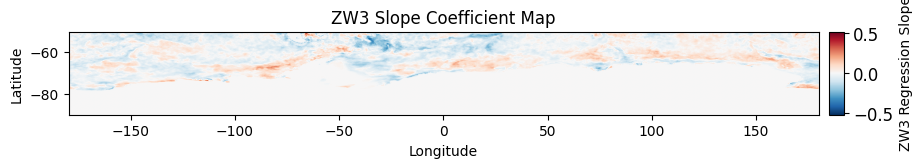

In [85]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(10, 12))

# Plot the image
im = ax.imshow(zw3_coef_map,
               cmap='RdBu_r',
               vmin=-np.nanmax(abs(zw3_coef_map)),
               vmax=np.nanmax(abs(zw3_coef_map)),
               extent=[lon.min(), lon.max(), lat.min(), lat.max()],
               origin='lower')

plt.title('ZW3 Slope Coefficient Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Create a divider for the existing axes instance
divider = make_axes_locatable(ax)

# Append axes to the right of ax, with width 5% of ax and padding 0.1 inch
cax = divider.append_axes("right", size="2%", pad=0.1)

# Create the colorbar in the new axes
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('ZW3 Regression Slope')

# Optionally, increase tick label size
cbar.ax.tick_params(labelsize=12)

plt.show()



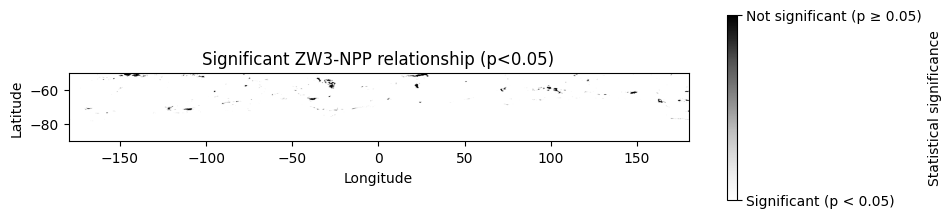

In [74]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(10, 12))

# Plot the boolean mask: True=significant (white), False=not significant (black)
im = ax.imshow(zw3_pval_map < 0.05,
               cmap='Greys',
               extent=[lon.min(), lon.max(), lat.min(), lat.max()],
               origin='lower')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Significant ZW3-NPP relationship (p<0.05)')

# Create colorbar with custom ticks and labels
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1], shrink = 0.2)
cbar.ax.set_yticklabels(['Significant (p < 0.05)','Not significant (p ≥ 0.05)'])
cbar.set_label('Statistical significance')


plt.show()



In [75]:
# #zw3 error map
# for i in range(NPP_2d.shape[1]):
#     y = NPP_2d[:, i]
#     if np.any(np.isnan(y)):
#         continue
#     model = LinearRegression().fit(X_zw3, y)
#     pred = model.predict(X_zw3)
#     residuals = y - pred
#
#     dof = len(y) - 2
#     s_err = np.sqrt(np.sum(residuals**2) / dof)
#     x_var = np.sum((X_zw3 - np.mean(X_zw3))**2)
#
#     if x_var == 0:
#         continue  # skip if zero variance
#
#     se_beta = s_err / np.sqrt(x_var)
#
#     # Store coefficient and standard error
#     zw3_coef[i] = model.coef_[0]
#     zw3_se[i] = se_beta


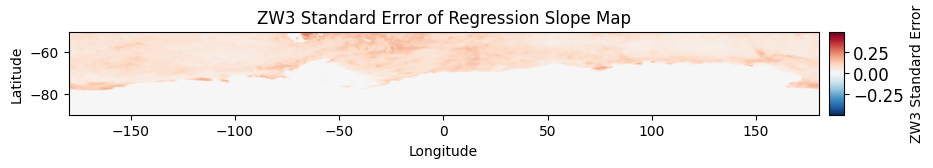

In [147]:
#plotting zw3 standard error
zw3_se_map = zw3_se.reshape(n_lat, n_lon)

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(10, 12))

# Plot the image
im = ax.imshow(zw3_se_map,
               cmap='RdBu_r',
               vmin=-np.nanmax(abs(zw3_se_map)),
               vmax=np.nanmax(abs(zw3_se_map)),
               extent=[lon.min(), lon.max(), lat.min(), lat.max()],
               origin='lower')

plt.title('ZW3 Standard Error of Regression Slope Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Create a divider for the existing axes instance
divider = make_axes_locatable(ax)

# Append axes to the right of ax, with width 5% of ax and padding 0.1 inch
cax = divider.append_axes("right", size="2%", pad=0.1)

# Create the colorbar in the new axes
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('ZW3 Standard Error')

# Optionally, increase tick label size
cbar.ax.tick_params(labelsize=12)

plt.show()


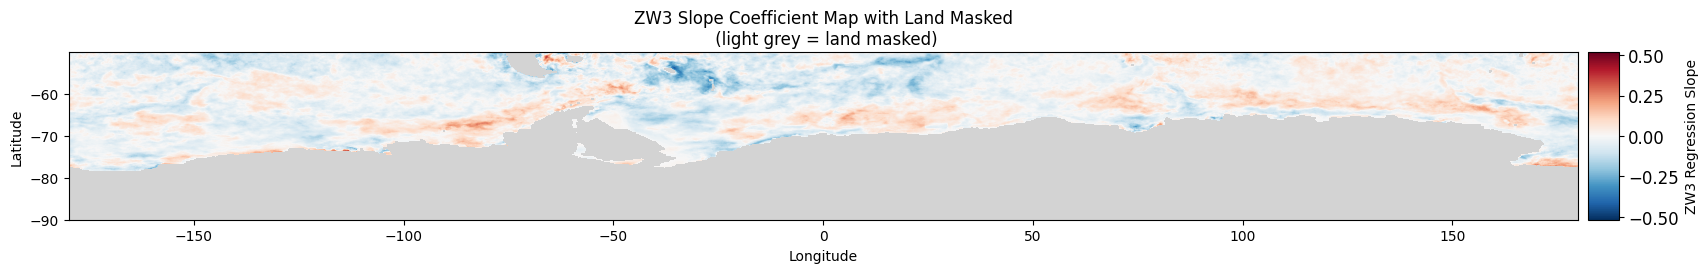

In [116]:
zw3_masked_coef_map = np.where(zw3_se_map == 0, np.nan, zw3_coef_map)

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import cm

fig, ax = plt.subplots(figsize=(20, 10))

cmap = cm.get_cmap('RdBu_r').copy()
cmap.set_bad(color='lightgray')  # land becomes light gray instead of white

# Plot the image
im = ax.imshow(zw3_masked_coef_map,
               cmap=cmap,
               vmin=-np.nanmax(abs(zw3_masked_coef_map)),
               vmax=np.nanmax(abs(zw3_masked_coef_map)),
               extent=[lon.min(), lon.max(), lat.min(), lat.max()],
               origin='lower')

plt.title('ZW3 Slope Coefficient Map with Land Masked\n (light grey = land masked)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Create a divider for the existing axes instance
divider = make_axes_locatable(ax)

# Append axes to the right of ax, with width 5% of ax and padding 0.1 inch
cax = divider.append_axes("right", size="2%", pad=0.1)

# Create the colorbar in the new axes
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('ZW3 Regression Slope')

# Optionally, increase tick label size
cbar.ax.tick_params(labelsize=12)

plt.show()




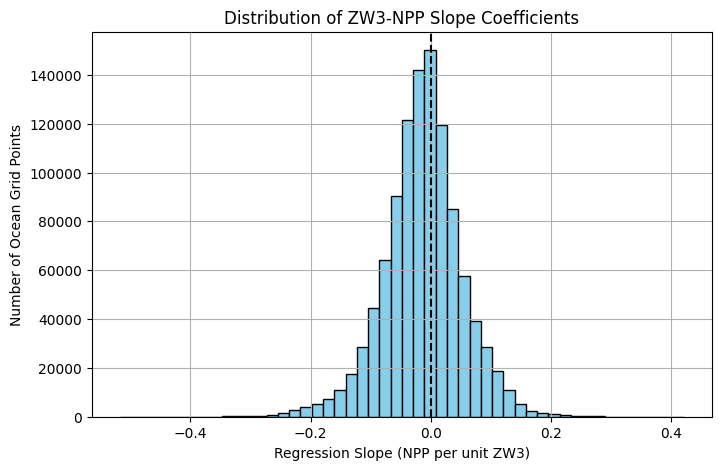

In [90]:
# Flatten the masked slope map (assuming masked_coef_map is already masked over land)
flattened_slope = zw3_masked_coef_map.flatten()

# Remove NaNs (land)
valid_slope = flattened_slope[~np.isnan(flattened_slope)]

# Plot histogram of slopes (distribution of relationships)
plt.figure(figsize=(8, 5))
plt.hist(valid_slope, bins=50, color='skyblue', edgecolor='k')
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribution of ZW3-NPP Slope Coefficients')
plt.xlabel('Regression Slope (NPP per unit ZW3)')
plt.ylabel('Number of Ocean Grid Points')
plt.grid(True)
plt.show()


In [117]:
print('NaNs in flattened_slope:', np.isnan(flattened_slope).sum())
print('Zeros in valid_slope:', np.sum(valid_slope == 0))


NaNs in flattened_slope: 1009798
Zeros in valid_slope: 0


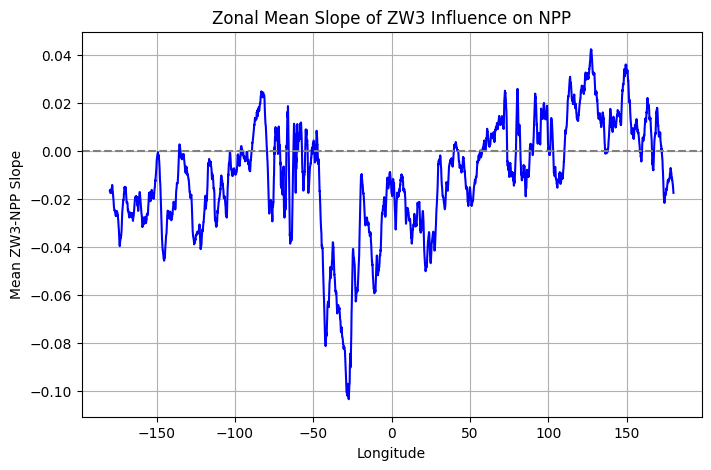

In [102]:
# average slopes over longitude (zonal mean)
zonal_slope = np.nanmean(zw3_masked_coef_map, axis=0)

plt.figure(figsize=(8, 5))
plt.plot(lon, zonal_slope, color='blue')
plt.axhline(0, linestyle='--', color='gray')
plt.xlabel('Longitude')
plt.ylabel('Mean ZW3-NPP Slope')
plt.title('Zonal Mean Slope of ZW3 Influence on NPP')
plt.grid(True)
plt.show()


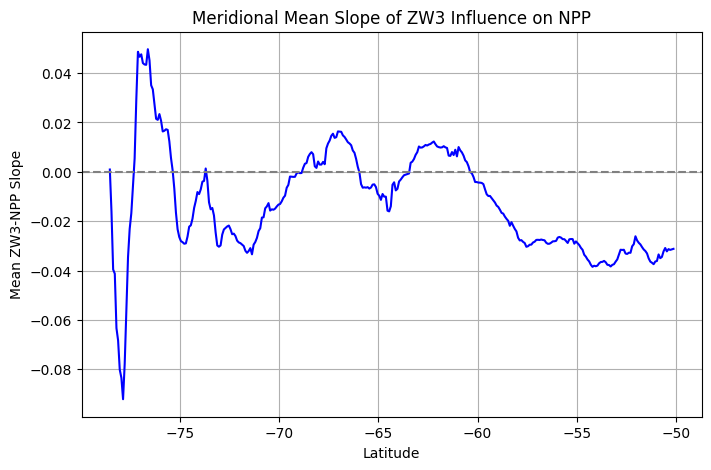

In [104]:
# average slopes over longitude (zonal mean)
meridional_slope = np.nanmean(zw3_masked_coef_map, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(lat, meridional_slope, color='blue')
plt.axhline(0, linestyle='--', color='gray')
plt.xlabel('Latitude')
plt.ylabel('Mean ZW3-NPP Slope')
plt.title('Meridional Mean Slope of ZW3 Influence on NPP')
plt.grid(True)
plt.show()


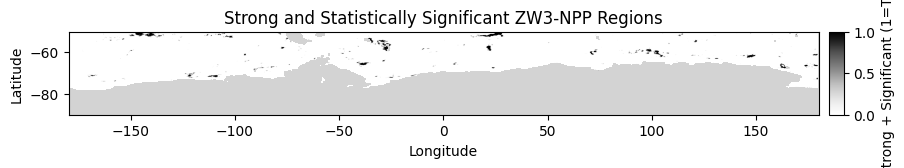

In [126]:
# Threshold for strong slope (e.g., > 90th percentile of all ocean slopes)
threshold = np.nanpercentile(valid_slope, 90)

# Create a mask of where slope is strong (above threshold)
strong_slope_mask = np.abs(zw3_masked_coef_map) >= threshold

significant_mask = zw3_pval_map < 0.05

strong_and_significant = strong_slope_mask & significant_mask
# Apply land mask (set land = NaN)
strong_and_significant_masked = np.where(zw3_se_map == 0, np.nan, strong_and_significant.astype(float))

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

cmap = cm.get_cmap('Greys').copy()
cmap.set_bad(color='lightgray')  # or use 'gray' / '#d3d3d3' for a lighter tone

fig, ax = plt.subplots(figsize=(10, 12))

im = ax.imshow(strong_and_significant_masked,
               cmap=cmap,
               vmin=0, vmax=1,
               extent=[lon.min(), lon.max(), lat.min(), lat.max()],
               origin='lower')

plt.title('Strong and Statistically Significant ZW3-NPP Regions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.1)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Strong + Significant (1=True)')
plt.show()


In [128]:
#linear regression for soi

from sklearn.linear_model import LinearRegression
from scipy.stats import t

soi_coef = np.full((n_lat * n_lon), np.nan)
soi_pval = np.full((n_lat * n_lon), np.nan)

X_soi = SOI_aligned_monthly['SOI'].values.reshape(-1, 1)

for i in range(NPP_2d.shape[1]):
    y = NPP_2d[:, i]
    if np.any(np.isnan(y)):
        continue
    model = LinearRegression().fit(X_soi, y)
    pred = model.predict(X_soi)
    residuals = y - pred
    dof = len(y) - 2
    s_err = np.sqrt(np.sum(residuals**2) / dof)
    x_var = np.sum((X_soi - np.mean(X_soi))**2)
    t_val = model.coef_[0] / (s_err / np.sqrt(x_var))
    p_val = 2 * (1 - t.cdf(abs(t_val), df=dof))

    soi_coef[i] = model.coef_[0]
    soi_pval[i] = p_val

# soi_coef_map = soi_coef.reshape(n_lat, n_lon)
# soi_pval_map = soi_pval.reshape(n_lat, n_lon)

In [129]:
#soi error map
soi_se = np.full((n_lat * n_lon), np.nan)

for i in range(NPP_2d.shape[1]):
    y = NPP_2d[:, i]
    if np.any(np.isnan(y)):
        continue
    model = LinearRegression().fit(X_soi, y)
    pred = model.predict(X_soi)
    residuals = y - pred

    dof = len(y) - 2
    s_err = np.sqrt(np.sum(residuals**2) / dof)
    x_var = np.sum((X_soi - np.mean(X_soi))**2)

    if x_var == 0:
        continue  # skip if zero variance

    se_beta = s_err / np.sqrt(x_var)

    # Store coefficient and standard error
    soi_coef[i] = model.coef_[0]
    soi_se[i] = se_beta


In [130]:
#reshape
soi_coef_map = soi_coef.reshape(n_lat, n_lon)
soi_pval_map = soi_pval.reshape(n_lat, n_lon)
soi_se = np.full((n_lat * n_lon), np.nan)

In [131]:
#plot maps for coefs and where it is statistically significant (SOI)
# plt.imshow(soi_coef_map, cmap='RdBu_r', vmin=-np.nanmax(abs(soi_coef_map)), vmax=np.nanmax(abs(soi_coef_map)))
# plt.title('SOI effect on NPP'); plt.colorbar(label='Regression coefficient')
# plt.show()
#
# plt.imshow(soi_pval_map < 0.05, cmap='Greys')
# plt.title('Significant SOI-NPP relationship (p < 0.05)')
# plt.show()


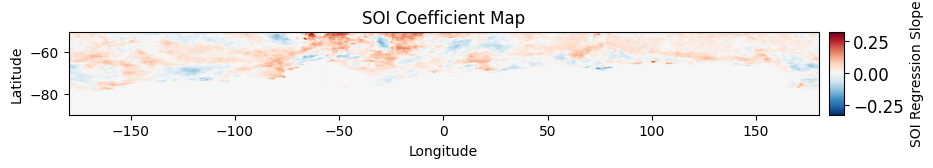

In [132]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(10, 12))

# Plot the image
im = ax.imshow(soi_coef_map,
               cmap='RdBu_r',
               vmin=-np.nanmax(abs(soi_coef_map)),
               vmax=np.nanmax(abs(soi_coef_map)),
               extent=[lon.min(), lon.max(), lat.min(), lat.max()],
               origin='lower')

plt.title('SOI Coefficient Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Create a divider for the existing axes instance
divider = make_axes_locatable(ax)

# Append axes to the right of ax, with width 5% of ax and padding 0.1 inch
cax = divider.append_axes("right", size="2%", pad=0.1)

# Create the colorbar in the new axes
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('SOI Regression Slope')

# Optionally, increase tick label size
cbar.ax.tick_params(labelsize=12)

plt.show()



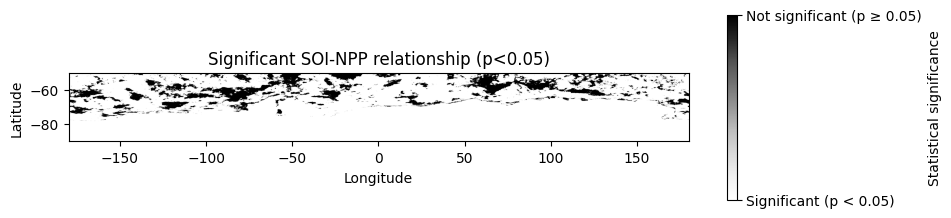

In [133]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(10, 12))

# Plot the boolean mask: True=significant (white), False=not significant (black)
im = ax.imshow(soi_pval_map < 0.05,
               cmap='Greys',
               extent=[lon.min(), lon.max(), lat.min(), lat.max()],
               origin='lower')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Significant SOI-NPP relationship (p<0.05)')

# Create colorbar with custom ticks and labels
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1], shrink = 0.2)
cbar.ax.set_yticklabels(['Significant (p < 0.05)','Not significant (p ≥ 0.05)'])
cbar.set_label('Statistical significance')


plt.show()



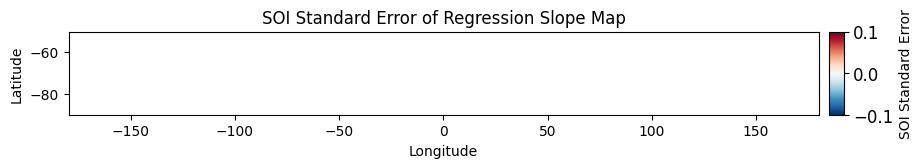

In [136]:
#plotting soi standard error
soi_se_map = soi_se.reshape(n_lat, n_lon)

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(10, 12))

# Plot the image
im = ax.imshow(soi_se_map,
               cmap='RdBu_r',
               vmin=-np.nanmax(abs(soi_se_map)),
               vmax=np.nanmax(abs(soi_se_map)),
               extent=[lon.min(), lon.max(), lat.min(), lat.max()],
               origin='lower')

plt.title('SOI Standard Error of Regression Slope Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Create a divider for the existing axes instance
divider = make_axes_locatable(ax)

# Append axes to the right of ax, with width 5% of ax and padding 0.1 inch
cax = divider.append_axes("right", size="2%", pad=0.1)

# Create the colorbar in the new axes
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('SOI Standard Error')

# Optionally, increase tick label size
cbar.ax.tick_params(labelsize=12)

plt.show()


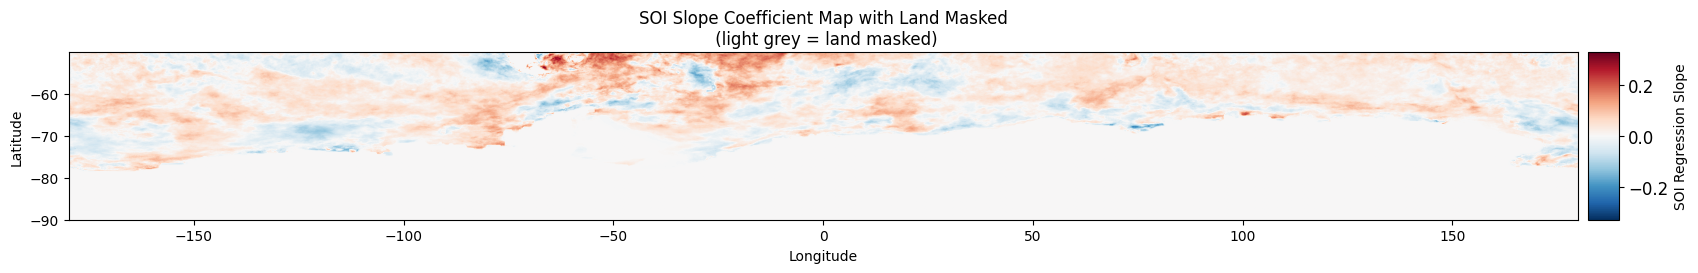

In [144]:
soi_masked_coef_map = np.where(soi_se_map == 0, np.nan, soi_coef_map)

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import cm

fig, ax = plt.subplots(figsize=(20, 10))

cmap = cm.get_cmap('RdBu_r').copy()
cmap.set_bad(color='lightgray')  # land becomes light gray instead of white

# Plot the image
im = ax.imshow(soi_masked_coef_map,
               cmap=cmap,
               vmin=-np.nanmax(abs(soi_masked_coef_map)),
               vmax=np.nanmax(abs(soi_masked_coef_map)),
               extent=[lon.min(), lon.max(), lat.min(), lat.max()],
               origin='lower')

plt.title('SOI Slope Coefficient Map with Land Masked\n (light grey = land masked)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Create a divider for the existing axes instance
divider = make_axes_locatable(ax)

# Append axes to the right of ax, with width 5% of ax and padding 0.1 inch
cax = divider.append_axes("right", size="2%", pad=0.1)

# Create the colorbar in the new axes
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('SOI Regression Slope')

# Optionally, increase tick label size
cbar.ax.tick_params(labelsize=12)

plt.show()







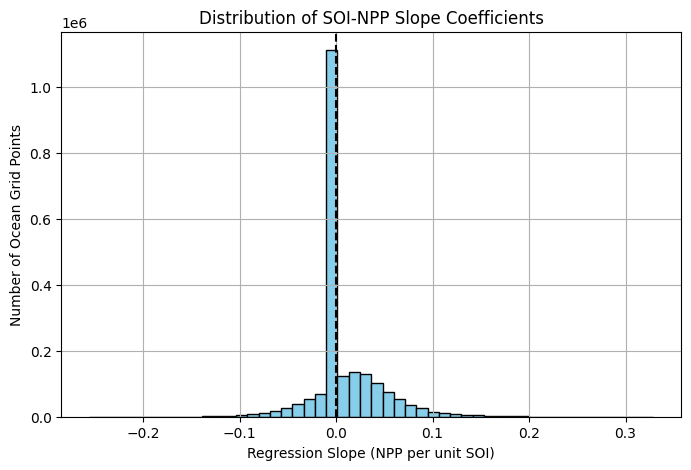

In [138]:
# Flatten the masked slope map (assuming masked_coef_map is already masked over land)
flattened_slope = soi_masked_coef_map.flatten()

# Remove NaNs (land)
valid_slope = flattened_slope[~np.isnan(flattened_slope)]

# Plot histogram of slopes (distribution of relationships)
plt.figure(figsize=(8, 5))
plt.hist(valid_slope, bins=50, color='skyblue', edgecolor='k')
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribution of SOI-NPP Slope Coefficients')
plt.xlabel('Regression Slope (NPP per unit SOI)')
plt.ylabel('Number of Ocean Grid Points')
plt.grid(True)
plt.show()


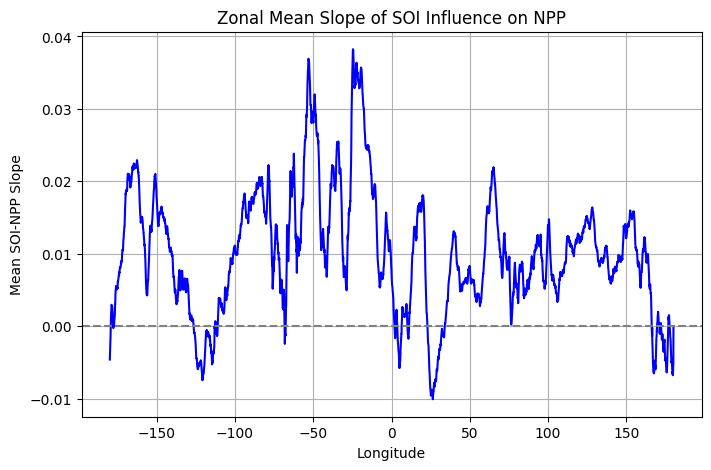

In [139]:
# average slopes over longitude (zonal mean)
zonal_slope = np.nanmean(soi_masked_coef_map, axis=0)

plt.figure(figsize=(8, 5))
plt.plot(lon, zonal_slope, color='blue')
plt.axhline(0, linestyle='--', color='gray')
plt.xlabel('Longitude')
plt.ylabel('Mean SOI-NPP Slope')
plt.title('Zonal Mean Slope of SOI Influence on NPP')
plt.grid(True)
plt.show()


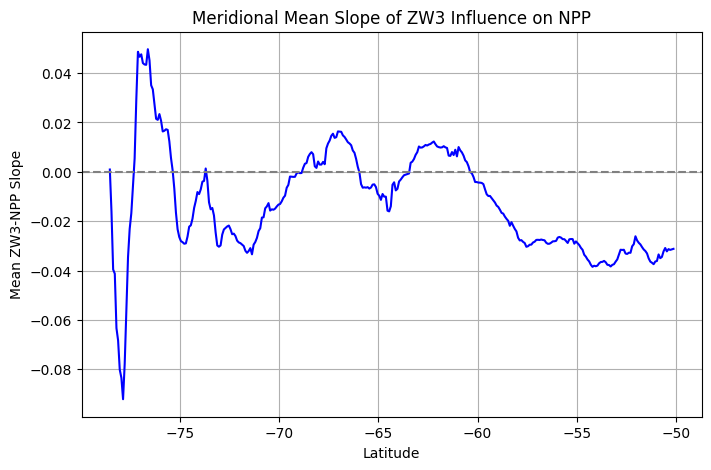

In [140]:
# average slopes over longitude (zonal mean)
meridional_slope = np.nanmean(zw3_masked_coef_map, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(lat, meridional_slope, color='blue')
plt.axhline(0, linestyle='--', color='gray')
plt.xlabel('Latitude')
plt.ylabel('Mean ZW3-NPP Slope')
plt.title('Meridional Mean Slope of ZW3 Influence on NPP')
plt.grid(True)
plt.show()


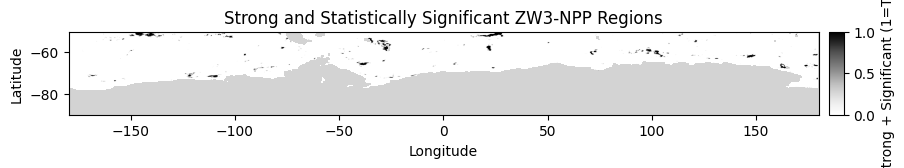

In [142]:
# Threshold for strong slope (e.g., > 90th percentile of all ocean slopes)
threshold = np.nanpercentile(valid_slope, 90)

# Create a mask of where slope is strong (above threshold)
strong_slope_mask = np.abs(zw3_masked_coef_map) >= threshold

significant_mask = zw3_pval_map < 0.05

strong_and_significant = strong_slope_mask & significant_mask
# Apply land mask (set land = NaN)
strong_and_significant_masked = np.where(zw3_se_map == 0, np.nan, strong_and_significant.astype(float))

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

cmap = cm.get_cmap('Greys').copy()
cmap.set_bad(color='lightgray')  # or use 'gray' / '#d3d3d3' for a lighter tone

fig, ax = plt.subplots(figsize=(10, 12))

im = ax.imshow(strong_and_significant_masked,
               cmap=cmap,
               vmin=0, vmax=1,
               extent=[lon.min(), lon.max(), lat.min(), lat.max()],
               origin='lower')

plt.title('Strong and Statistically Significant ZW3-NPP Regions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.1)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Strong + Significant (1=True)')
plt.show()


In [152]:
#multiple linear regression for SOI and ZW3 on NPP
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy import stats

# Reshape NPP to 2D: (time, pixels)
n_time, n_lat, n_lon = NPP_aligned.shape
NPP_2d = NPP_aligned.values.reshape(n_time, -1)  # shape: (196, 480*4320)

zw3_se_arr = np.empty(NPP_2d.shape[1])
soi_se_arr = np.empty(NPP_2d.shape[1])

# Combine predictors into shape (196, 2)
X = np.stack([
    ZW3_aligned['zw3index_magnitude'].values,
    SOI_aligned_monthly['SOI'].values
], axis=1)

# Fit linear model for each pixel
reg = LinearRegression()
betas = np.empty((3, NPP_2d.shape[1]))  # intercept + 2 predictors

for i in range(NPP_2d.shape[1]):
    y = NPP_2d[:, i]
    if np.any(np.isnan(y)):
        betas[:, i] = np.nan
    else:
        reg.fit(X, y)
        betas[0, i] = reg.intercept_
        betas[1:, i] = reg.coef_


n_obs, n_pred = X.shape  # 196, 2
p_values = np.empty((2, NPP_2d.shape[1]))  # exclude intercept

for i in range(NPP_2d.shape[1]):
    y = NPP_2d[:, i]
    if np.any(np.isnan(y)):
        p_values[:, i] = np.nan
    else:
        model = LinearRegression().fit(X, y)
        y_pred = model.predict(X)
        residuals = y - y_pred
        dof = n_obs - n_pred - 1
        sse = np.sum(residuals**2)
        mse = sse / dof
        var_b = mse * np.linalg.inv(X.T @ X).diagonal()
        zw3_se_arr[i] = np.sqrt(var_b[0])
        soi_se_arr[i] = np.sqrt(var_b[1])
        t_stats = model.coef_ / np.sqrt(var_b)
        p = 2 * (1 - stats.t.cdf(np.abs(t_stats), dof))
        p_values[:, i] = p


# Reshape coefficients to (lat, lon)
intercept_map = betas[0].reshape(n_lat, n_lon)
zw3_map = betas[1].reshape(n_lat, n_lon)
soi_map = betas[2].reshape(n_lat, n_lon)

zw3_p_map = p_values[0].reshape(n_lat, n_lon)
soi_p_map = p_values[1].reshape(n_lat, n_lon)

zw3_se_map = zw3_se_arr.reshape(n_lat, n_lon)
soi_se_map = soi_se_arr.reshape(n_lat, n_lon)


KeyboardInterrupt: 

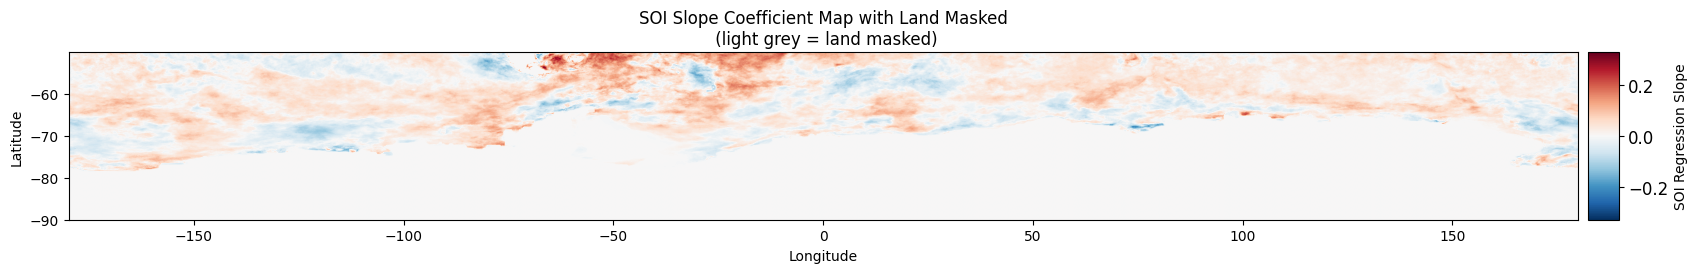

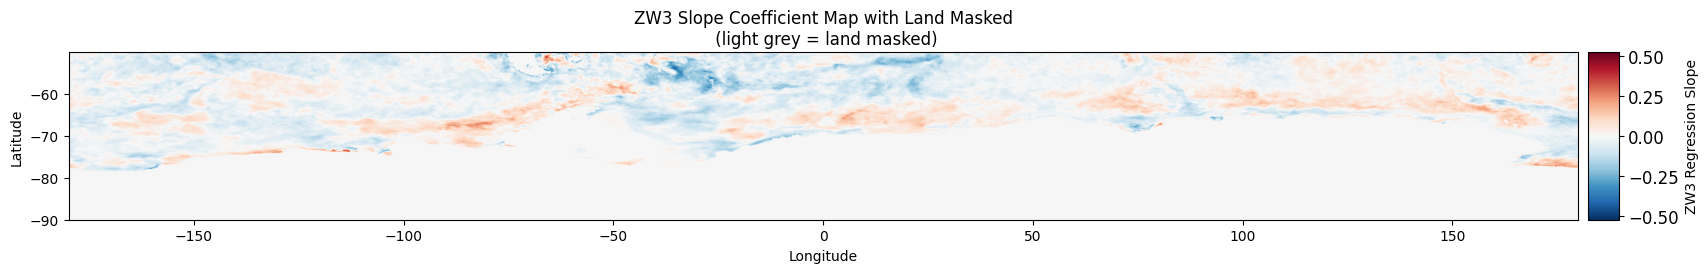

In [153]:
# soi_map = np.where(soi_se_map == 0, np.nan, soi_map)

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import cm

fig, ax = plt.subplots(figsize=(20, 10))

cmap = cm.get_cmap('RdBu_r').copy()
cmap.set_bad(color='lightgray')  # land becomes light gray instead of white

# Plot the image
im = ax.imshow(soi_map,
               cmap=cmap,
               vmin=-np.nanmax(abs(soi_map)),
               vmax=np.nanmax(abs(soi_map)),
               extent=[lon.min(), lon.max(), lat.min(), lat.max()],
               origin='lower')

plt.title('SOI Slope Coefficient Map with Land Masked\n (light grey = land masked)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Create a divider for the existing axes instance
divider = make_axes_locatable(ax)

# Append axes to the right of ax, with width 5% of ax and padding 0.1 inch
cax = divider.append_axes("right", size="2%", pad=0.1)

# Create the colorbar in the new axes
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('SOI Regression Slope')

# Optionally, increase tick label size
cbar.ax.tick_params(labelsize=12)

plt.show()


# zw3_map = np.where(zw3_map == 0, np.nan, zw3_map)

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import cm

fig, ax = plt.subplots(figsize=(20, 10))

cmap = cm.get_cmap('RdBu_r').copy()
cmap.set_bad(color='lightgray')  # land becomes light gray instead of white

# Plot the image
im = ax.imshow(zw3_map,
               cmap=cmap,
               vmin=-np.nanmax(abs(zw3_map)),
               vmax=np.nanmax(abs(zw3_map)),
               extent=[lon.min(), lon.max(), lat.min(), lat.max()],
               origin='lower')

plt.title('ZW3 Slope Coefficient Map with Land Masked\n (light grey = land masked)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Create a divider for the existing axes instance
divider = make_axes_locatable(ax)

# Append axes to the right of ax, with width 5% of ax and padding 0.1 inch
cax = divider.append_axes("right", size="2%", pad=0.1)

# Create the colorbar in the new axes
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('ZW3 Regression Slope')

# Optionally, increase tick label size
cbar.ax.tick_params(labelsize=12)

plt.show()



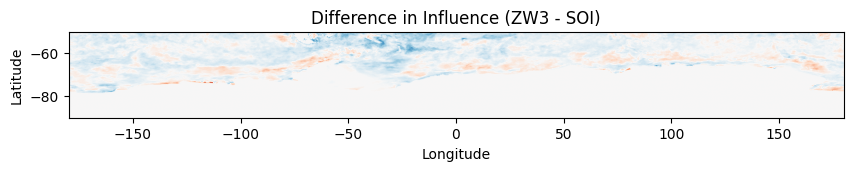

In [156]:
influence_diff = zw3_map - soi_map

plt.figure(figsize=(10, 6))
im = plt.imshow(influence_diff,
                cmap='RdBu_r',
                vmin=-np.nanmax(abs(influence_diff)),
                vmax=np.nanmax(abs(influence_diff)),
                extent=[lon.min(), lon.max(), lat.min(), lat.max()],
                origin='lower')
# plt.colorbar(im, shrink=0.7, label='ZW3 - SOI Slope')
plt.title('Difference in Influence (ZW3 - SOI)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Create a divider for the existing axes instance
divider = make_axes_locatable(ax)

# Append axes to the right of ax, with width 5% of ax and padding 0.1 inch
cax = divider.append_axes("right", size="2%", pad=0.1)

# Create the colorbar in the new axes
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('ZW3 - SOI Slope')

# Optionally, increase tick label size
cbar.ax.tick_params(labelsize=12)

plt.show()


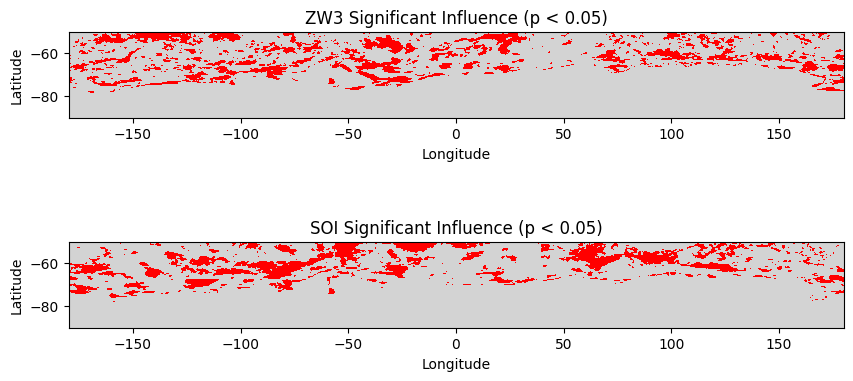

In [169]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

zw3_sig_mask = zw3_p_map < 0.05
soi_sig_mask = soi_p_map < 0.05

# Custom colormap: red for significant, light gray for not
cmap = ListedColormap(['lightgray', 'red'])

fig, axs = plt.subplots(2, 1, figsize=(10, 5))

# ZW3 significance
im1 = axs[0].imshow(zw3_sig_mask,
                    cmap=cmap,
                    extent=[lon.min(), lon.max(), lat.min(), lat.max()],
                    origin='lower',
                    vmin=0, vmax=1)
axs[0].set_title('ZW3 Significant Influence (p < 0.05)')
axs[0].set_xlabel('Longitude')
axs[0].set_ylabel('Latitude')

# SOI significance
im2 = axs[1].imshow(soi_sig_mask,
                    cmap=cmap,
                    extent=[lon.min(), lon.max(), lat.min(), lat.max()],
                    origin='lower',
                    vmin=0, vmax=1)
axs[1].set_title('SOI Significant Influence (p < 0.05)')
axs[1].set_xlabel('Longitude')
axs[1].set_ylabel('Latitude')

plt.show()


/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/
remapcon
Spearman r: 0.691232863733136, p: 3.510835242933671e-29
Spearman r: 0.6505796205681891, p: 5.711192013043226e-25
Spearman r: 0.5639356198285704, p: 7.538075114695917e-18
Spearman r: 0.6146204522954324, p: 9.535191425201438e-22
Cumulative sum of squares: [0.39289733 0.57188538 0.67835367 0.74909831 0.81217049 0.85565999
 0.88578828 0.9098856  0.93231207 0.94848196 0.96341577 0.97474373
 0.98381343 0.99195115 0.9998569 ]
Squared covariance fraction: [0.39289733 0.17898806 0.10646829 0.07074464 0.06307218 0.0434895
 0.03012829 0.02409732 0.02242647 0.01616989 0.01493381 0.01132796
 0.00906969 0.00813773 0.00790575]
<class 'numpy.ndarray'>
15
PCA fraction [0.39289732629741203, 0.17898805829689235, 0.10646828815892628, 0.07074464038726236, 0.06307217985930158, 0.04348949524646473, 0.030128293124151884, 0.02409731792727121, 0.022426474105561423, 0.01616988656772278, 0.01493381429880214, 0.011327959755031536, 0.00906969146830

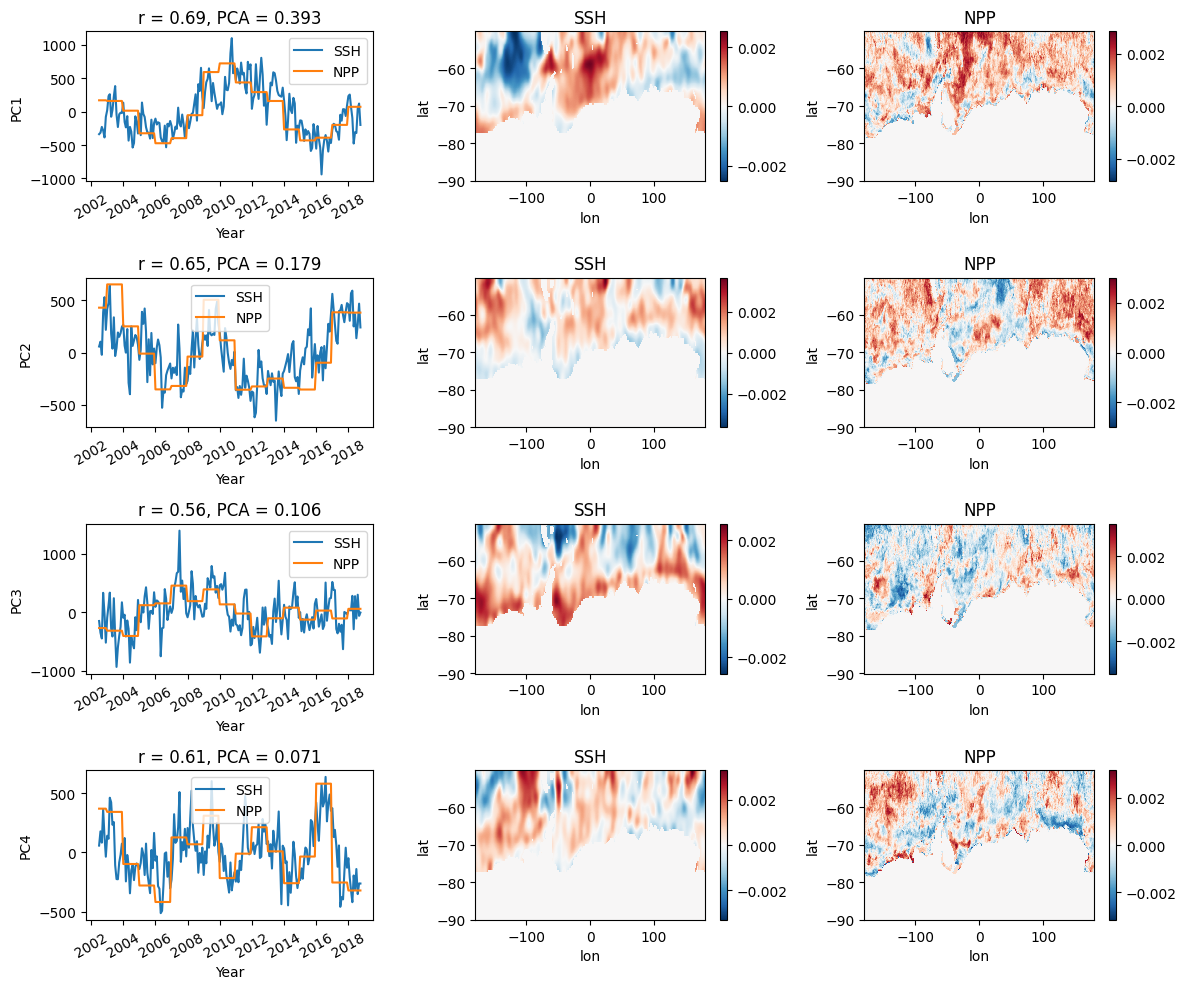

In [40]:
import inspect

model = xe.cross.MCA(n_modes=15, standardize=True)
#print(dir(model))

#print(ws_curl_xa.dims)
model.fit(dot_xa, NPP_xa, dim='time')
#model.fit(ws_curl_eumetsat_xa, NPP_xa, dim='time')
#model.fit(dot_xa, NPP_ocean_masked_xa, dim='time')
comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)
s1 = scores1.values;
s2 = scores2.values
c1 = comps1.values;
c2 = comps2.values
print(path)
print(gridtype)
# Full path to the 'results' directory
# results_dir = os.path.join(path, 'results')
#
# # Check if the directory already exists
# if os.path.exists(results_dir):
#     print("Directory already exists")
# else:
#     # Create the directory if it doesn't exist
#     os.makedirs(results_dir, exist_ok=True)
#     print("Directory created!")
# # write PCs on files
# # fname = path + 'results/PCs_dot_' + gridtype + '.txt'
# fname = path + 'results/PCs_dot_' + gridtype + '_seas.txt'
# with open(fname, 'w') as file:
#     file.write('time\tPC1\tPC2\tPC3\n')
#     for i in range(len(time_dot)):
#         file.write(f'{time_dot[i]}\t{s1[0,i]}\t{s1[1,i]}\t{s1[2,i]}\n')
# file.close()
#
# # fname = path + 'results/PCs_ws_curl_' + gridtype + '.txt'
# fname = path + 'results/PCs_ws_curl_' + gridtype + '_seas.txt'
# with open(fname, 'w') as file:
#     file.write('time\tPC1\tPC2\tPC3\n')
#     for i in range(len(time_dot)):
#         file.write(f'{time_dot[i]}\t{s2[0,i]}\t{s2[1,i]}\t{s2[2,i]}\n')
# file.close()
#how can you change from using cross.MCA to calling the subplots PCA1, PCA2, PCA3 etc ...
r_pears = [];
p_pears = []
r_spear = [];
p_spear = []
for m in range(1, 5):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2));
    p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    print(f"Spearman r: {r}, p: {p}")
    r_spear.append(np.round(r, 2));
    p_spear.append(np.round(p, 5))

sq_cov_frac = model.squared_covariance_fraction()
scf = sq_cov_frac.values
cum_sum = np.cumsum(scf)
print('Cumulative sum of squares:', cum_sum)
print('Squared covariance fraction:', scf)
print(type(cum_sum))
print(len(cum_sum))
mode_percent = []
for i in range(len(cum_sum)):
    if i == 0:
        each_mode_percent = float(cum_sum[i])
        mode_percent.append(each_mode_percent)
    else:
        each_mode_percent = float(cum_sum[i] - cum_sum[i - 1])
        mode_percent.append(each_mode_percent)
print('PCA fraction', mode_percent)
print('Spearman p value: ',p_spear)

fig = plt.figure(figsize=(12, 10))

for i in range(0, 4):
    j = 3 * i + 1  # a = 2*(i+1) + i - 1

    plt.subplot(4, 3, j)
    scores1.sel(mode=i + 1).plot(label='SSH')
    scores2.sel(mode=i + 1).plot(label='NPP')
    plt.title("r = {}, PCA = {:.3f}".format(r_spear[i], mode_percent[i]))
    plt.xlabel('Year');
    plt.ylabel('PC' + str(int(i + 1)))
    plt.xticks(rotation=30)
    plt.legend()

    plt.subplot(4, 3, j + 1)
    comps1.sel(mode=i + 1).plot()
    plt.title('SSH')

    plt.subplot(4, 3, j + 2)
    comps2.sel(mode=i + 1).plot()
    plt.title('NPP')

fig.tight_layout()

# fig.savefig(path + 'results/MCA_output_' + gridtype + '_seas.png')
# compute squared covariance fraction (equivalent to explained variance in PCA)


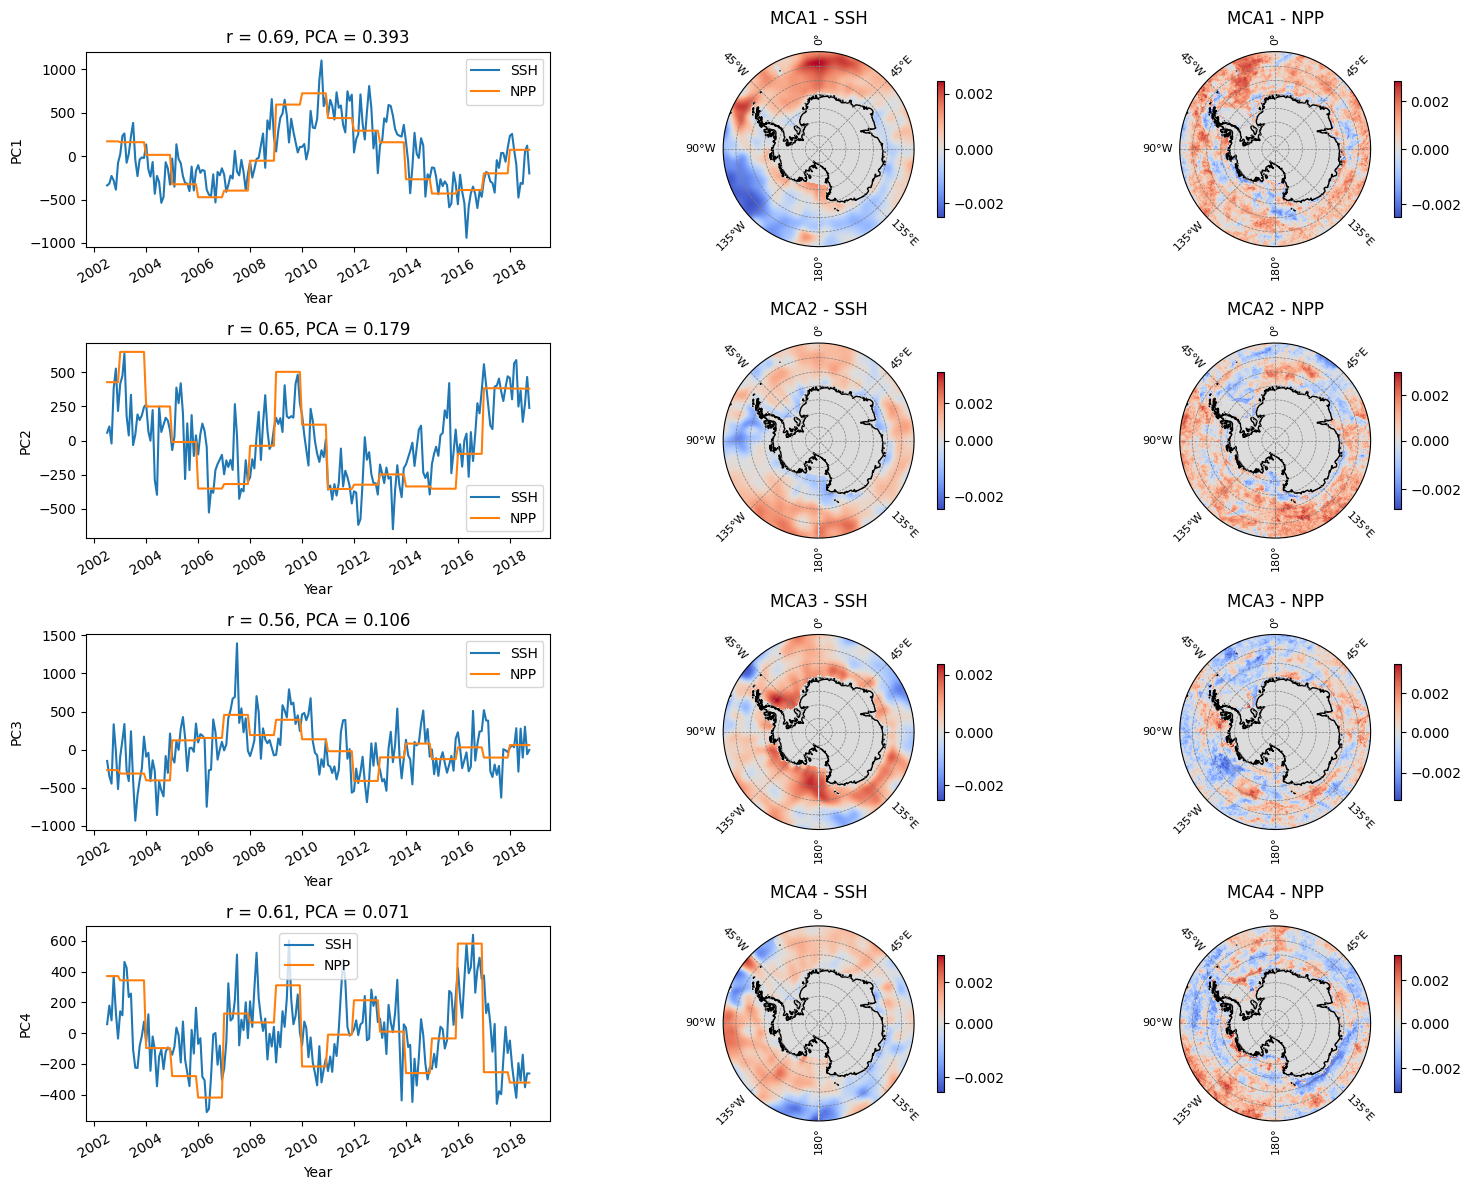

In [41]:
from polar_plot_utils import plot_curvilinear_data
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib import colors
import scipy.stats
from matplotlib.gridspec import GridSpec

# Assuming comps1 and comps2 are already defined (MCA components)
comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)
s1 = scores1.values
s2 = scores2.values
c1 = comps1.values
c2 = comps2.values


# Initialize lists for correlation coefficients
r_pears = []
p_pears = []
r_spear = []
p_spear = []

# Calculate correlation coefficients
for m in range(1, 5):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2))
    p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    r_spear.append(np.round(r, 2))
    p_spear.append(np.round(p, 2))

# Create the figure and GridSpec
fig = plt.figure(figsize=(15, 12))  # Adjust figure size to accommodate bigger columns
gs = GridSpec(4, 3, figure=fig, width_ratios=[2, 2, 2])  # Column widths: 1 for column 1, 2 for columns 2 and 3

# Loop over modes 1 to 4 and plot results
for i in range(0, 4):
    j = 3 * i  # Column position for scores plots

    # Plot scores (time series) in 1st column
    ax1 = fig.add_subplot(gs[i, 0])  # Use gs to position the subplot in the 1st column
    scores1.sel(mode=i + 1).plot(ax=ax1, label='SSH')
    scores2.sel(mode=i + 1).plot(ax=ax1, label='NPP')
    ax1.set_title("r = {}, PCA = {:.3f}".format(r_spear[i], mode_percent[i]))
    ax1.set_xlabel('Year')
    ax1.set_ylabel('PC' + str(int(i + 1)))
    ax1.tick_params(axis='x', rotation=30)
    ax1.legend()

    # Create circular plot for SSH in 2nd column
    ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.SouthPolarStereo())  # 2nd column (bigger)
    comp1 = comps1.sel(mode=i + 1)
    lat = comp1.lat.values
    lon = comp1.lon.values
    data1 = comp1.values
    plot_curvilinear_data(ax2, data1,lon, lat, "MCA" + str(i + 1) + " - SSH")

    # Create circular plot for WSC in 3rd column
    ax3 = fig.add_subplot(gs[i, 2], projection=ccrs.SouthPolarStereo())  # 3rd column (bigger)
    comp2 = comps2.sel(mode=i + 1)
    data2 = comp2.values
    plot_curvilinear_data(ax3, data2, lon,lat, "MCA" + str(i + 1) + " - NPP")

# Adjust layout to prevent overlap
fig.tight_layout()
plt.show()


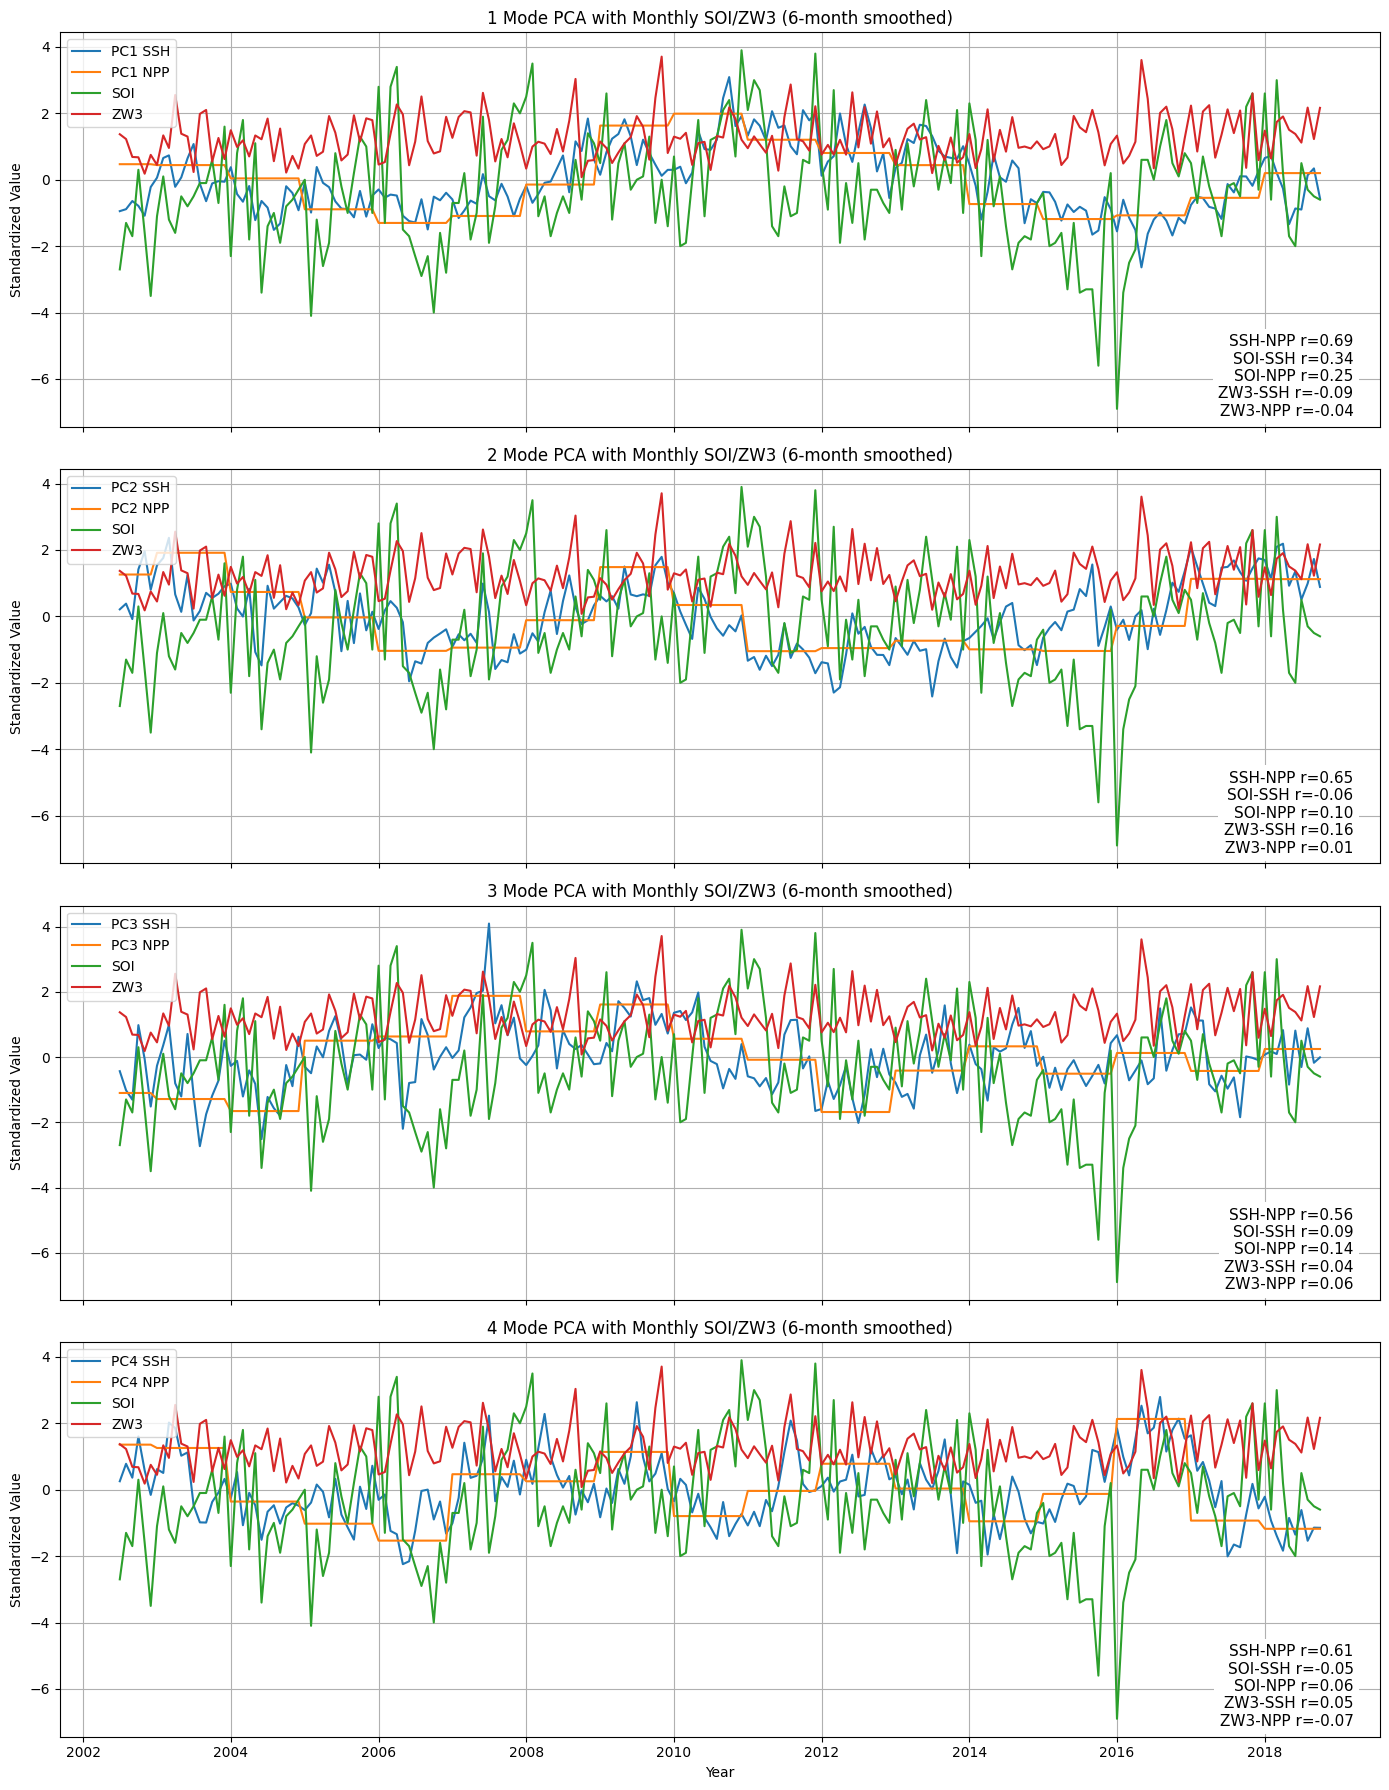

In [45]:
import matplotlib.pyplot as plt
import scipy.stats

modes = [1, 2, 3, 4]

fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)

for idx, mode in enumerate(modes):
    pc_ssh = (scores1.sel(mode=mode) - scores1.sel(mode=mode).mean()) / scores1.sel(mode=mode).std()
    pc_npp = (scores2.sel(mode=mode) - scores2.sel(mode=mode).mean()) / scores2.sel(mode=mode).std()

    # Calculate correlations
    r_ssh_npp, _ = scipy.stats.spearmanr(pc_ssh.values, pc_npp.values)
    r_soi_ssh, _ = scipy.stats.spearmanr(SOI_aligned_monthly_masked['SOI'].values, pc_ssh.values)
    r_soi_npp, _ = scipy.stats.spearmanr(SOI_aligned_monthly_masked['SOI'].values, pc_npp.values)
    r_zw3_ssh, _ = scipy.stats.spearmanr(ZW3_aligned['zw3index_magnitude'].values, pc_ssh.values)
    r_zw3_npp, _ = scipy.stats.spearmanr(ZW3_aligned['zw3index_magnitude'].values, pc_npp.values)

    ax = axes[idx]
    ax.plot(pc_ssh.time, pc_ssh, label=f"PC{mode} SSH")
    ax.plot(pc_npp.time, pc_npp, label=f"PC{mode} NPP")
    ax.plot(NPP_xa.time, SOI_aligned_monthly_masked['SOI'].values, label="SOI")
    ax.plot(NPP_xa.time, ZW3_aligned['zw3index_magnitude'].values, label="ZW3")

    ax.set_ylabel("Standardized Value")
    ax.set_title(f"{mode} Mode PCA with Monthly SOI/ZW3 (6-month smoothed)")
    ax.grid(True)
    ax.legend(loc="upper left")

    corr_text = (
        f"SSH-NPP r={r_ssh_npp:.2f}\n"
        f"SOI-SSH r={r_soi_ssh:.2f}\n"
        f"SOI-NPP r={r_soi_npp:.2f}\n"
        f"ZW3-SSH r={r_zw3_ssh:.2f}\n"
        f"ZW3-NPP r={r_zw3_npp:.2f}"
    )
    ax.text(0.98, 0.02, corr_text, transform=ax.transAxes,
            fontsize=11, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(facecolor='white', edgecolor='none'))

axes[-1].set_xlabel("Year")

plt.tight_layout()
plt.show()


/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/
remapcon
Spearman r: 0.4570528118326927, p: 1.6522614693090847e-11
Spearman r: 0.41922240009951184, p: 9.617154116579225e-10
Spearman r: 0.41789081558927826, p: 1.0997342934877861e-09
Spearman r: 0.45785591376152657, p: 1.5073206730434504e-11
Cumulative sum of squares: [0.27228113 0.4416871  0.53527273 0.6241909  0.69163252 0.75254045
 0.80655008 0.84477605 0.87720409 0.90575568 0.93377945 0.95611673
 0.97308384 0.98824083 0.99983495]
Squared covariance fraction: [0.27228113 0.16940597 0.09358564 0.08891817 0.06744162 0.06090793
 0.05400963 0.03822598 0.03242803 0.0285516  0.02802376 0.02233728
 0.01696712 0.01515699 0.01159412]
<class 'numpy.ndarray'>
15
PCA fraction [0.27228113081167626, 0.16940596659133744, 0.09358563538293885, 0.08891816914792816, 0.0674416196725397, 0.06090792746338969, 0.05400962890702088, 0.03822597585084442, 0.03242803229738778, 0.02855159673964036, 0.028023762388244777, 0.022337282007004244, 0.01696711

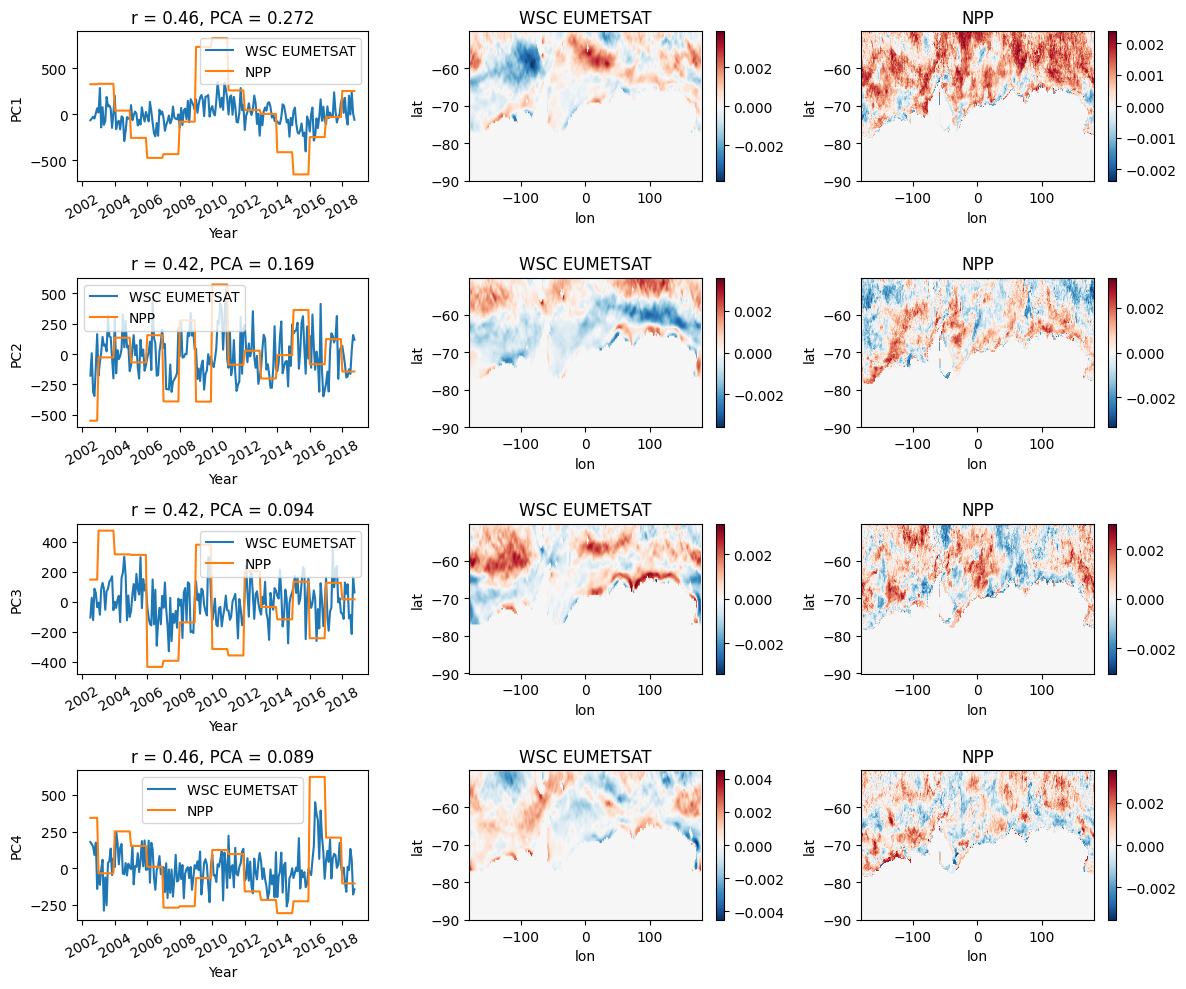

In [46]:
import inspect

model = xe.cross.MCA(n_modes=15, standardize=True)
#print(dir(model))

#print(ws_curl_xa.dims)
#model.fit(dot_xa, NPP_xa, dim='time')
model.fit(ws_curl_eumetsat_xa, NPP_xa, dim='time')
#model.fit(dot_xa, NPP_ocean_masked_xa, dim='time')
comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)
s1 = scores1.values;
s2 = scores2.values
c1 = comps1.values;
c2 = comps2.values
print(path)
print(gridtype)
# Full path to the 'results' directory
# results_dir = os.path.join(path, 'results')
#
# # Check if the directory already exists
# if os.path.exists(results_dir):
#     print("Directory already exists")
# else:
#     # Create the directory if it doesn't exist
#     os.makedirs(results_dir, exist_ok=True)
#     print("Directory created!")
# # write PCs on files
# # fname = path + 'results/PCs_dot_' + gridtype + '.txt'
# fname = path + 'results/PCs_dot_' + gridtype + '_seas.txt'
# with open(fname, 'w') as file:
#     file.write('time\tPC1\tPC2\tPC3\n')
#     for i in range(len(time_dot)):
#         file.write(f'{time_dot[i]}\t{s1[0,i]}\t{s1[1,i]}\t{s1[2,i]}\n')
# file.close()
#
# # fname = path + 'results/PCs_ws_curl_' + gridtype + '.txt'
# fname = path + 'results/PCs_ws_curl_' + gridtype + '_seas.txt'
# with open(fname, 'w') as file:
#     file.write('time\tPC1\tPC2\tPC3\n')
#     for i in range(len(time_dot)):
#         file.write(f'{time_dot[i]}\t{s2[0,i]}\t{s2[1,i]}\t{s2[2,i]}\n')
# file.close()
#how can you change from using cross.MCA to calling the subplots PCA1, PCA2, PCA3 etc ...
r_pears = [];
p_pears = []
r_spear = [];
p_spear = []
for m in range(1, 5):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2));
    p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    print(f"Spearman r: {r}, p: {p}")
    r_spear.append(np.round(r, 2));
    p_spear.append(np.round(p, 5))

sq_cov_frac = model.squared_covariance_fraction()
scf = sq_cov_frac.values
cum_sum = np.cumsum(scf)
print('Cumulative sum of squares:', cum_sum)
print('Squared covariance fraction:', scf)
print(type(cum_sum))
print(len(cum_sum))
mode_percent = []
for i in range(len(cum_sum)):
    if i == 0:
        each_mode_percent = float(cum_sum[i])
        mode_percent.append(each_mode_percent)
    else:
        each_mode_percent = float(cum_sum[i] - cum_sum[i - 1])
        mode_percent.append(each_mode_percent)
print('PCA fraction', mode_percent)
print('Spearman p value: ',p_spear)

fig = plt.figure(figsize=(12, 10))

for i in range(0, 4):
    j = 3 * i + 1  # a = 2*(i+1) + i - 1

    plt.subplot(4, 3, j)
    scores1.sel(mode=i + 1).plot(label='WSC EUMETSAT')
    scores2.sel(mode=i + 1).plot(label='NPP')
    plt.title("r = {}, PCA = {:.3f}".format(r_spear[i], mode_percent[i]))
    plt.xlabel('Year');
    plt.ylabel('PC' + str(int(i + 1)))
    plt.xticks(rotation=30)
    plt.legend()

    plt.subplot(4, 3, j + 1)
    comps1.sel(mode=i + 1).plot()
    plt.title('WSC EUMETSAT')

    plt.subplot(4, 3, j + 2)
    comps2.sel(mode=i + 1).plot()
    plt.title('NPP')

fig.tight_layout()

# fig.savefig(path + 'results/MCA_output_' + gridtype + '_seas.png')
# compute squared covariance fraction (equivalent to explained variance in PCA)


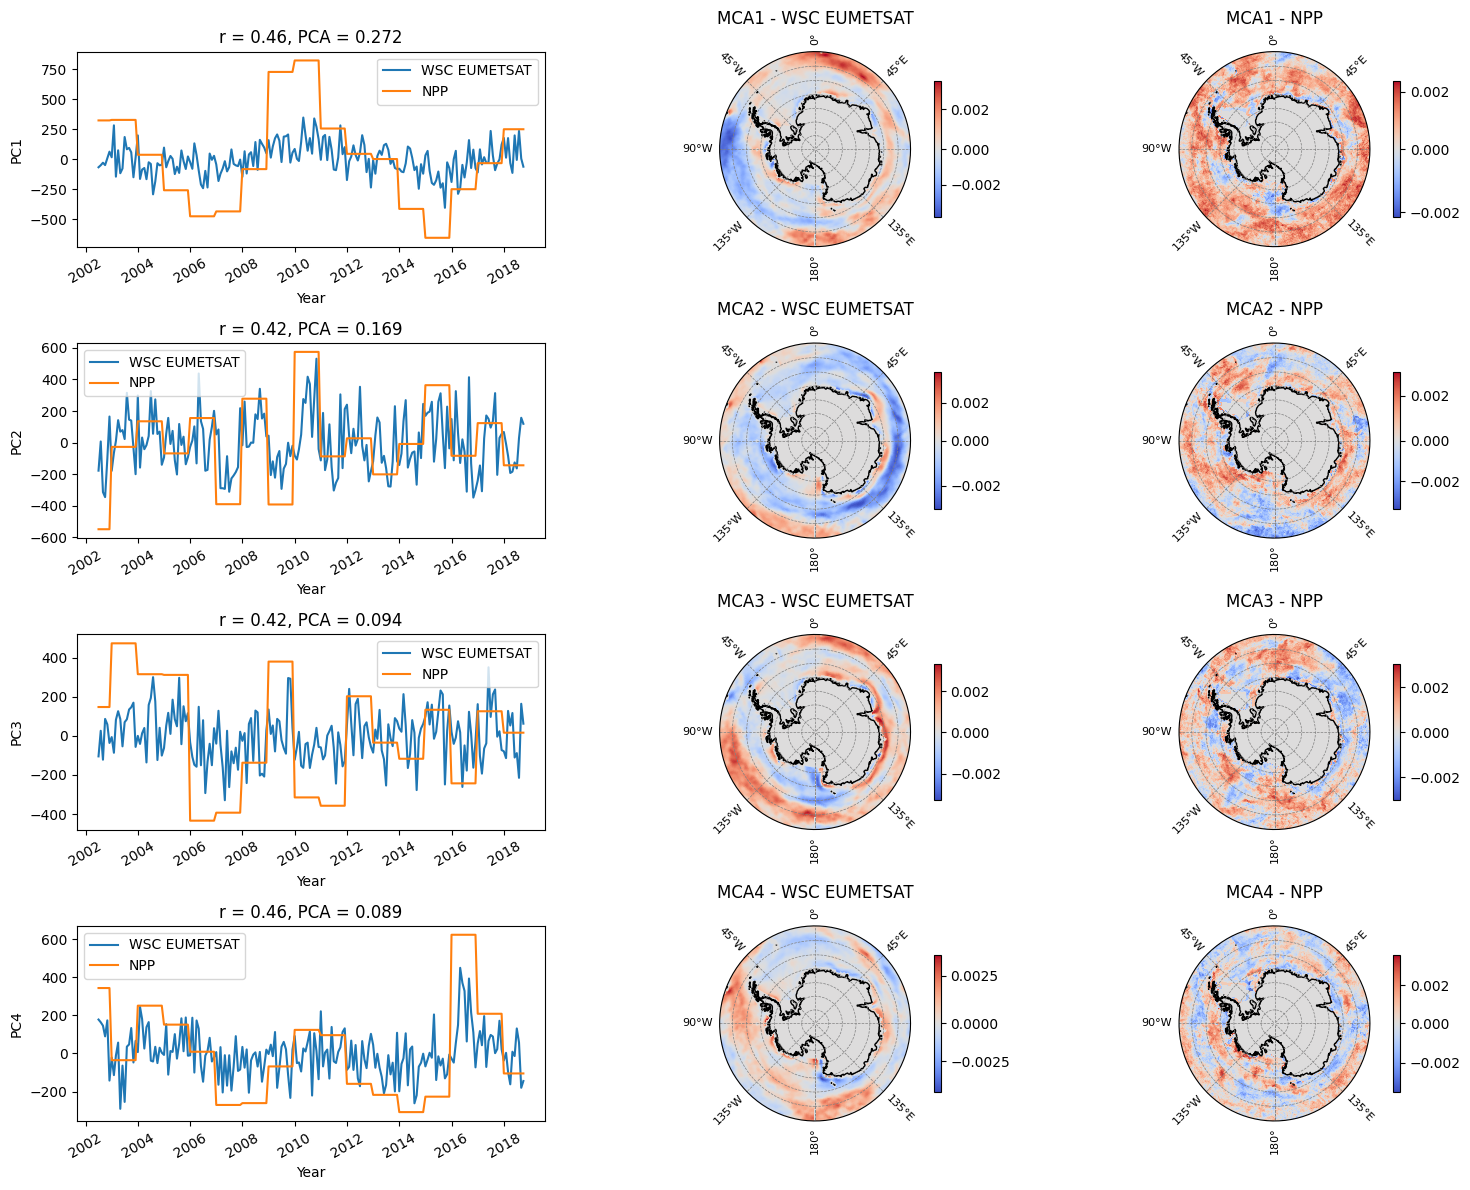

In [47]:
from polar_plot_utils import plot_curvilinear_data
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib import colors
import scipy.stats
from matplotlib.gridspec import GridSpec

# Assuming comps1 and comps2 are already defined (MCA components)
comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)
s1 = scores1.values
s2 = scores2.values
c1 = comps1.values
c2 = comps2.values


# Initialize lists for correlation coefficients
r_pears = []
p_pears = []
r_spear = []
p_spear = []

# Calculate correlation coefficients
for m in range(1, 5):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2))
    p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    r_spear.append(np.round(r, 2))
    p_spear.append(np.round(p, 2))

# Create the figure and GridSpec
fig = plt.figure(figsize=(15, 12))  # Adjust figure size to accommodate bigger columns
gs = GridSpec(4, 3, figure=fig, width_ratios=[2, 2, 2])  # Column widths: 1 for column 1, 2 for columns 2 and 3

# Loop over modes 1 to 4 and plot results
for i in range(0, 4):
    j = 3 * i  # Column position for scores plots

    # Plot scores (time series) in 1st column
    ax1 = fig.add_subplot(gs[i, 0])  # Use gs to position the subplot in the 1st column
    scores1.sel(mode=i + 1).plot(ax=ax1, label='WSC EUMETSAT')
    scores2.sel(mode=i + 1).plot(ax=ax1, label='NPP')
    ax1.set_title("r = {}, PCA = {:.3f}".format(r_spear[i], mode_percent[i]))
    ax1.set_xlabel('Year')
    ax1.set_ylabel('PC' + str(int(i + 1)))
    ax1.tick_params(axis='x', rotation=30)
    ax1.legend()

    # Create circular plot for SSH in 2nd column
    ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.SouthPolarStereo())  # 2nd column (bigger)
    comp1 = comps1.sel(mode=i + 1)
    lat = comp1.lat.values
    lon = comp1.lon.values
    data1 = comp1.values
    plot_curvilinear_data(ax2, data1,lon, lat, "MCA" + str(i + 1) + " - WSC EUMETSAT")

    # Create circular plot for WSC in 3rd column
    ax3 = fig.add_subplot(gs[i, 2], projection=ccrs.SouthPolarStereo())  # 3rd column (bigger)
    comp2 = comps2.sel(mode=i + 1)
    data2 = comp2.values
    plot_curvilinear_data(ax3, data2, lon,lat, "MCA" + str(i + 1) + " - NPP")

# Adjust layout to prevent overlap
fig.tight_layout()
plt.show()


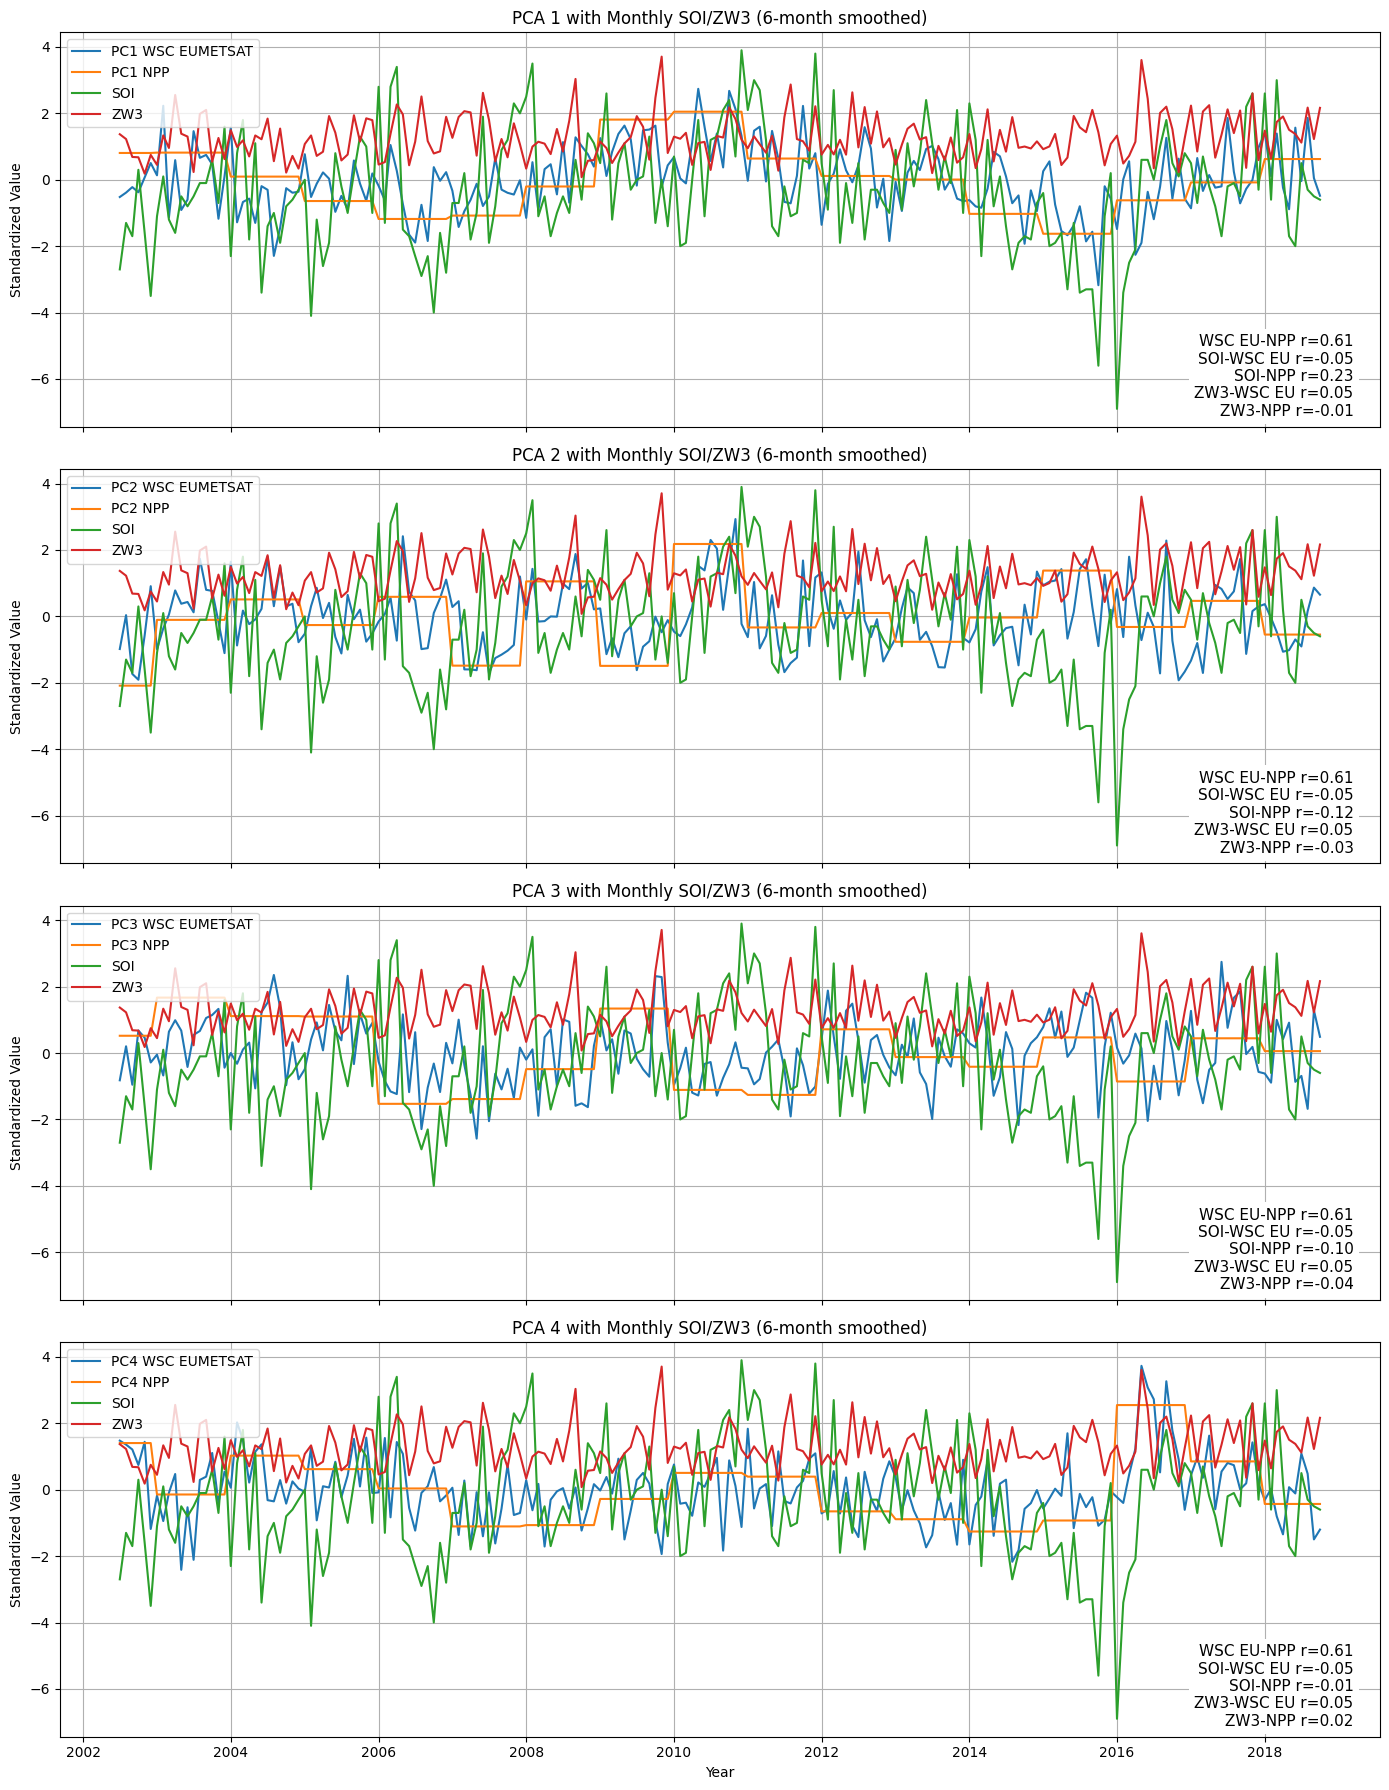

In [48]:
import matplotlib.pyplot as plt
import scipy.stats

modes = [1, 2, 3, 4]

fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)

for idx, mode in enumerate(modes):
    pc_wsc = (scores1.sel(mode=mode) - scores1.sel(mode=mode).mean()) / scores1.sel(mode=mode).std()
    pc_npp = (scores2.sel(mode=mode) - scores2.sel(mode=mode).mean()) / scores2.sel(mode=mode).std()

    # Calculate correlations
    r_wsc_npp, _ = scipy.stats.spearmanr(pc_ssh.values, pc_npp.values)
    r_soi_wsc, _ = scipy.stats.spearmanr(SOI_aligned_monthly_masked['SOI'].values, pc_wsc.values)
    r_soi_npp, _ = scipy.stats.spearmanr(SOI_aligned_monthly_masked['SOI'].values, pc_npp.values)
    r_zw3_wsc, _ = scipy.stats.spearmanr(ZW3_aligned['zw3index_magnitude'].values, pc_wsc.values)
    r_zw3_npp, _ = scipy.stats.spearmanr(ZW3_aligned['zw3index_magnitude'].values, pc_npp.values)

    ax = axes[idx]
    ax.plot(pc_wsc.time, pc_wsc, label=f"PC{mode} WSC EUMETSAT")
    ax.plot(pc_npp.time, pc_npp, label=f"PC{mode} NPP")
    ax.plot(NPP_xa.time, SOI_aligned_monthly_masked['SOI'].values, label="SOI")
    ax.plot(NPP_xa.time, ZW3_aligned['zw3index_magnitude'].values, label="ZW3")

    ax.set_ylabel("Standardized Value")
    ax.set_title(f"PCA {mode} with Monthly SOI/ZW3 (6-month smoothed)")
    ax.grid(True)
    ax.legend(loc="upper left")

    corr_text = (
        f"WSC EU-NPP r={r_ssh_npp:.2f}\n"
        f"SOI-WSC EU r={r_soi_ssh:.2f}\n"
        f"SOI-NPP r={r_soi_npp:.2f}\n"
        f"ZW3-WSC EU r={r_zw3_ssh:.2f}\n"
        f"ZW3-NPP r={r_zw3_npp:.2f}"
    )
    ax.text(0.98, 0.02, corr_text, transform=ax.transAxes,
            fontsize=11, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(facecolor='white', edgecolor='none'))

axes[-1].set_xlabel("Year")

plt.tight_layout()
plt.show()
